# Análisis y explotación de datos del Observatorio Astronómico Virtual 

Este notebook presenta un flujo de analisis limpio y reproducible sobre `dataset_v1.csv` generado por el ETL.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Compatibilidad entre matplotlib 3.6.x y matplotlib-inline 0.2.x
if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 140)

## 1. Carga del CSV

Partimos del archivo generado por el ETL.

In [2]:
csv_path = 'dataset_v1.csv'
df = pd.read_csv(csv_path)

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
df.head()

Filas: 10,000 | Columnas: 22


,source_id,ra,dec,parallax,parallax_error,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,phot_g_mean_flux,phot_g_mean_flux_error,phot_bp_mean_flux,phot_bp_mean_flux_error,phot_rp_mean_flux,phot_rp_mean_flux_error,classprob_dsc_combmod_star,logg_gspphot,clase_real,e_Gmag,e_BPmag,e_RPmag,abs_mag_g
0,174340590925522688,70.995063,35.830178,0.540838,0.025441,14.544000,15.594014,13.535884,2.058130,28664.671513,5.384592,7903.349038,8.420289,30535.464594,15.535185,1.000000,3.3108,Gigante,0.000204,0.001157,0.000552,3.209335
1,44833106315510784,55.155989,18.164681,1.743235,0.082516,16.988377,18.471436,15.789686,2.681749,3017.145075,2.934002,558.267717,10.889171,3830.749486,10.965418,0.998850,4.0937,Enana,0.001056,0.021177,0.003108,8.195156
2,17874421231032576,50.679983,13.322081,0.942112,0.026938,14.827709,15.348033,14.138805,1.209228,22073.084131,7.445678,9912.964962,47.522213,17524.111066,14.645075,0.999981,4.1390,Enana,0.000366,0.005205,0.000907,4.698221
3,45199415485577856,62.378361,15.399348,1.454421,0.039003,15.269318,15.915274,14.483748,1.431525,14696.695799,4.916098,5879.054477,16.976084,12754.363555,23.043633,0.999977,4.5229,Enana,0.000363,0.003135,0.001962,6.082769
4,43685456694244480,57.222866,16.993743,1.432564,0.069485,16.943250,17.795677,16.033890,1.761787,3145.185462,2.260729,1040.269416,10.016609,3059.160320,16.555890,0.999928,4.6468,Enana,0.000780,0.010454,0.005876,7.723822


## 2. Calidad y estructura de datos

Verificamos tipos, valores ausentes, duplicados y consistencia general.

In [3]:
print('Informacion general:')
display(df.info())

missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(3)
missing_table = pd.DataFrame({'missing': missing, 'missing_pct': missing_pct})
display(missing_table[missing_table['missing'] > 0])

duplicates = df.duplicated(subset=['source_id']).sum() if 'source_id' in df.columns else df.duplicated().sum()
print(f'Duplicados detectados: {duplicates}')

if 'clase_real' in df.columns:
    display(df['clase_real'].value_counts(dropna=False).to_frame('conteo'))

Informacion general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   source_id                   10000 non-null  int64  
 1   ra                          10000 non-null  float64
 2   dec                         10000 non-null  float64
 3   parallax                    10000 non-null  float64
 4   parallax_error              10000 non-null  float64
 5   phot_g_mean_mag             10000 non-null  float64
 6   phot_bp_mean_mag            10000 non-null  float64
 7   phot_rp_mean_mag            10000 non-null  float64
 8   bp_rp                       10000 non-null  float64
 9   phot_g_mean_flux            10000 non-null  float64
 10  phot_g_mean_flux_error      10000 non-null  float64
 11  phot_bp_mean_flux           10000 non-null  float64
 12  phot_bp_mean_flux_error     10000 non-null  float64
 13  phot_rp_mea

None

,missing,missing_pct


Duplicados detectados: 0


,conteo
Gigante,5000
Enana,5000


## 3. Variables predictoras objetivo

Variables seleccionadas para modelado:
- `phot_g_mean_mag` (G)
- `phot_bp_mean_mag` (BP)
- `phot_rp_mean_mag` (RP)
- `bp_rp` (indice de color BP-RP)
- `e_Gmag`, `e_BPmag`, `e_RPmag` (errores fotometricos)

In [4]:
predictoras = [
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag',
    'bp_rp',
    'e_Gmag',
    'e_BPmag',
    'e_RPmag',
]

faltantes = [c for c in predictoras if c not in df.columns]
if faltantes:
    raise ValueError(f'Faltan variables predictoras en el CSV: {faltantes}')

print('Todas las variables predictoras estan presentes.')
display(df[predictoras].describe().T)

Todas las variables predictoras estan presentes.


,count,mean,std,min,25%,50%,75%,max
phot_g_mean_mag,10000.0,13.864497,1.946692,4.515971,12.677206,13.822419,15.250069,17.998570
phot_bp_mean_mag,10000.0,14.614418,2.078453,5.266807,13.372602,14.535215,15.859486,20.029953
phot_rp_mean_mag,10000.0,13.045356,1.893883,3.684473,11.877285,13.018459,14.502189,16.838291
bp_rp,10000.0,1.569062,0.487818,0.081288,1.218019,1.486348,1.829183,4.029451
e_Gmag,10000.0,0.000422,0.000495,0.000088,0.000203,0.000274,0.000450,0.018825
e_BPmag,10000.0,0.004391,0.008972,0.000226,0.000820,0.001303,0.003243,0.106554
e_RPmag,10000.0,0.001531,0.002122,0.000136,0.000449,0.000752,0.001786,0.048997


## 4. Exploración descriptiva

Se exploran distribuciones de las variables mas importantes y el balance por clase.

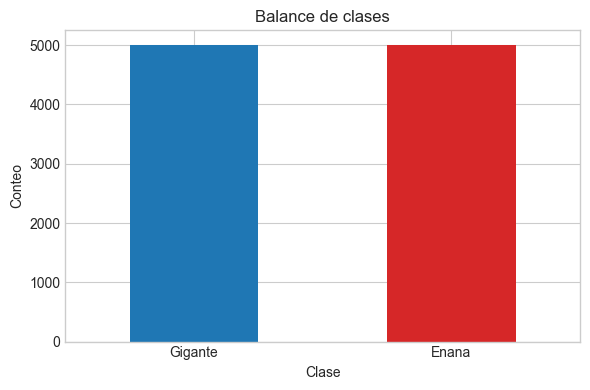

In [5]:
# Balance de clases
if 'clase_real' in df.columns:
    ax = df['clase_real'].value_counts().plot(kind='bar', color=['#1f77b4', '#d62728'], figsize=(6, 4))
    ax.set_title('Balance de clases')
    ax.set_xlabel('Clase')
    ax.set_ylabel('Conteo')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

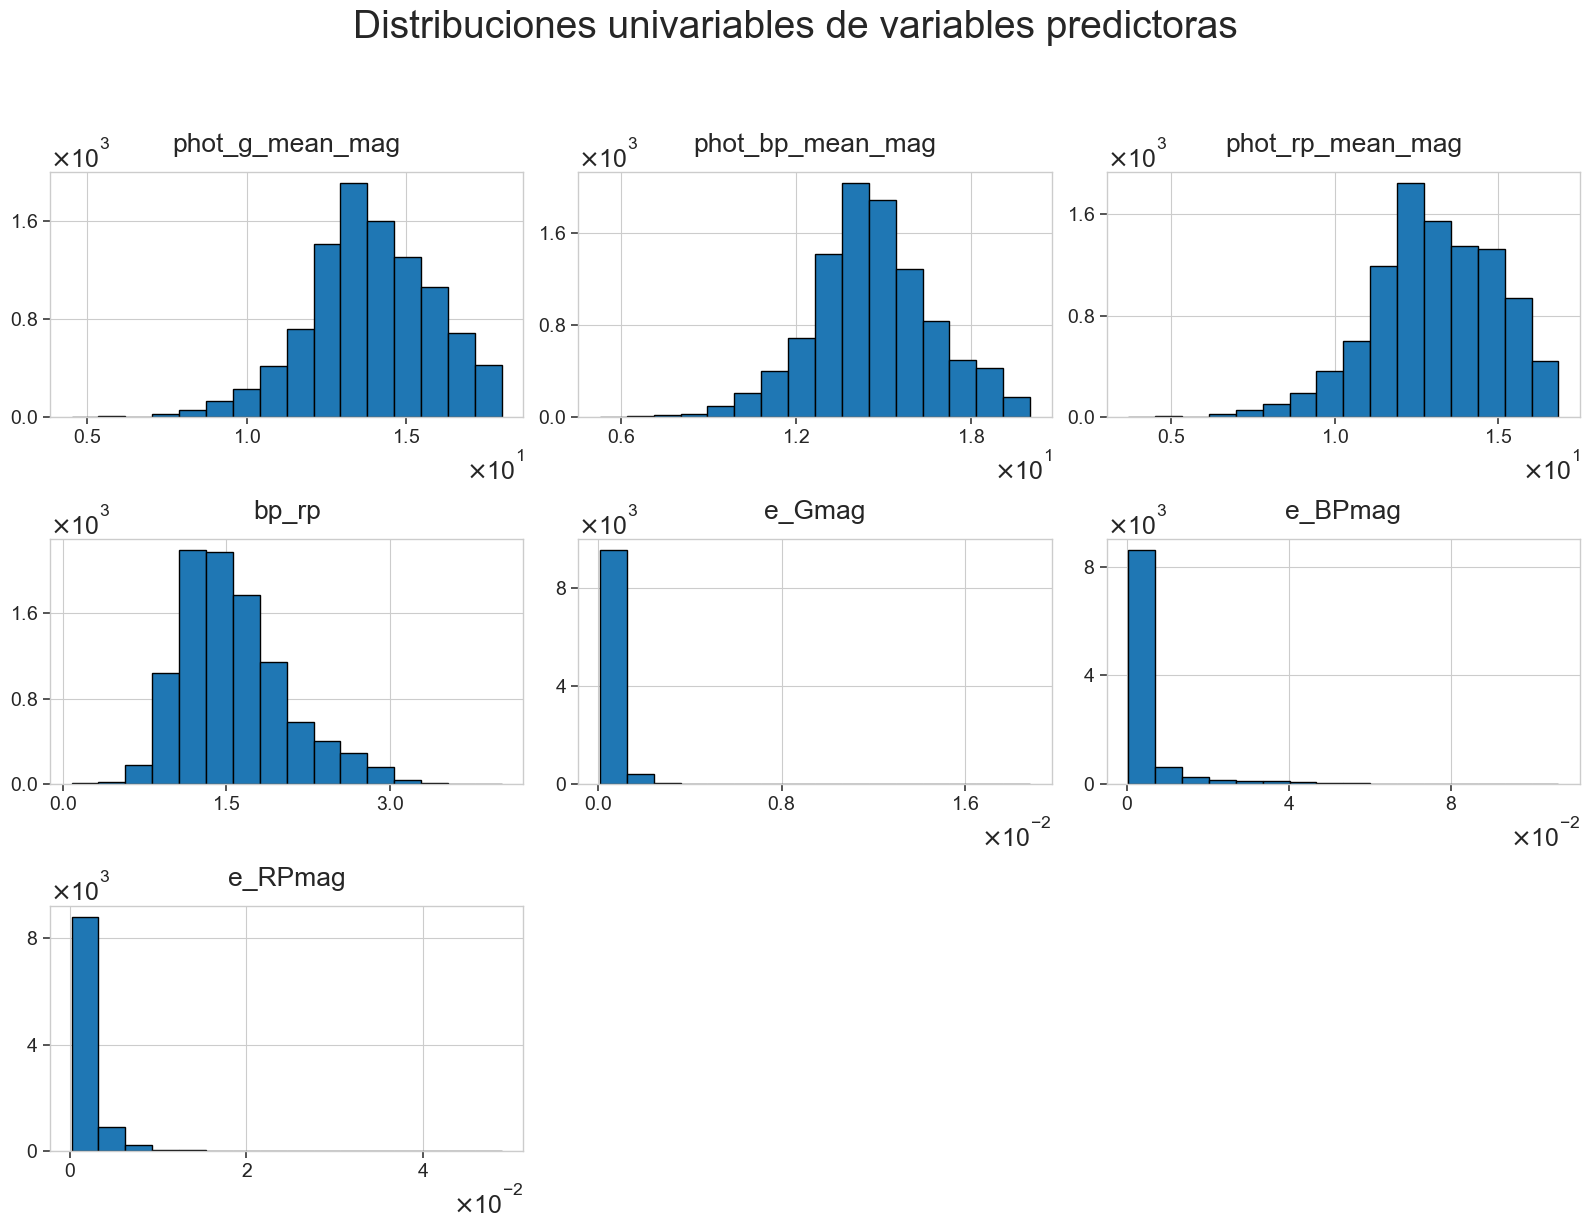

In [6]:
# Histogramas de predictores
from matplotlib.ticker import MaxNLocator, ScalarFormatter

axes = df[predictoras].hist(figsize=(16, 12), bins=16, edgecolor='black')

for ax in axes.flatten():
    # Hacer mas visibles los nombres de variables y los ejes
    ax.set_title(ax.get_title(), fontsize=19, pad=14)
    ax.set_xlabel(ax.get_xlabel(), fontsize=16, labelpad=10)
    ax.set_ylabel(ax.get_ylabel(), fontsize=16, labelpad=10)
    ax.tick_params(axis='both', labelsize=14, width=1.1, length=5)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
    ax.ticklabel_format(axis='x', style='sci', scilimits=(0, 0))
    ax.yaxis.get_offset_text().set_fontsize(18)
    ax.xaxis.get_offset_text().set_fontsize(18)

plt.suptitle('Distribuciones univariables de variables predictoras', fontsize=28, y=1.02)
plt.tight_layout()
plt.show()

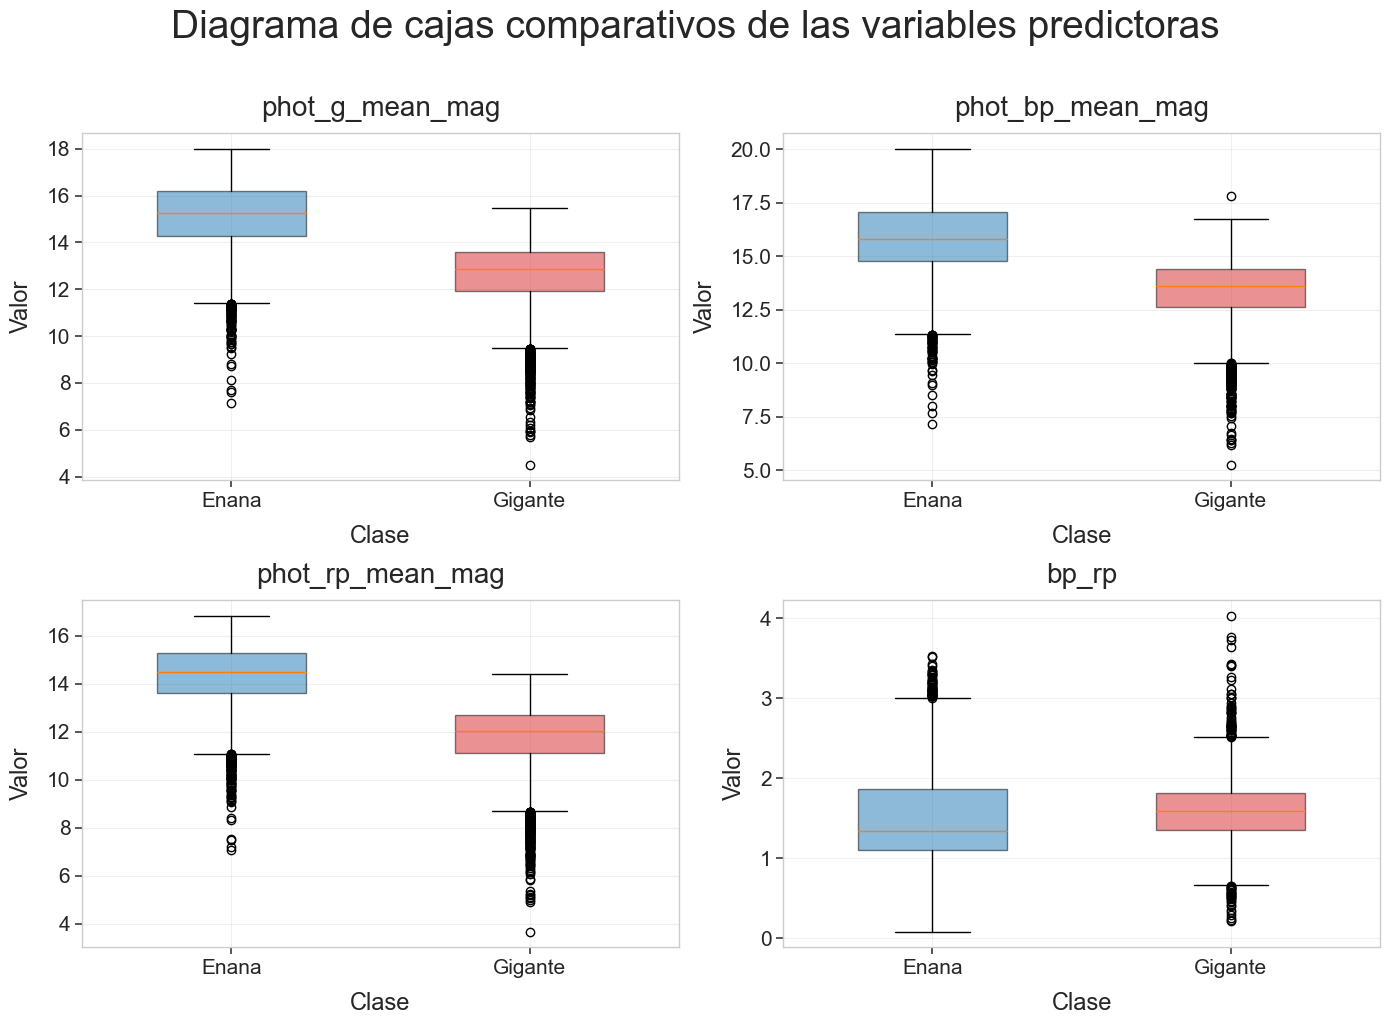

In [7]:
# Boxplots por clase para detectar separabilidad y outliers
if 'clase_real' in df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    cols_plot = ['phot_g_mean_mag', 'phot_bp_mean_mag', 'phot_rp_mean_mag', 'bp_rp']
    for ax, col in zip(axes.flatten(), cols_plot):
        for clase, color in [('Enana', '#1f77b4'), ('Gigante', '#d62728')]:
            datos = df.loc[df['clase_real'] == clase, col].dropna()
            ax.boxplot(datos, positions=[0 if clase == 'Enana' else 1], widths=0.5, patch_artist=True,
                       boxprops=dict(facecolor=color, alpha=0.5))
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Enana', 'Gigante'], fontsize=16)
        ax.set_title(col, fontsize=20, pad=12)
        ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
        ax.set_xlabel('Clase', fontsize=17, labelpad=10)
        ax.set_ylabel('Valor', fontsize=17, labelpad=10)
        ax.grid(alpha=0.3)
    plt.suptitle('Diagrama de cajas comparativos de las variables predictoras', fontsize=28, y=1.02)
    plt.tight_layout()
    plt.show()

## 5. Diagrama H-R (Hertzsprung-Russell)

Visualización principal para validar consistencia entre color (`BP-RP`) y magnitud absoluta en G.

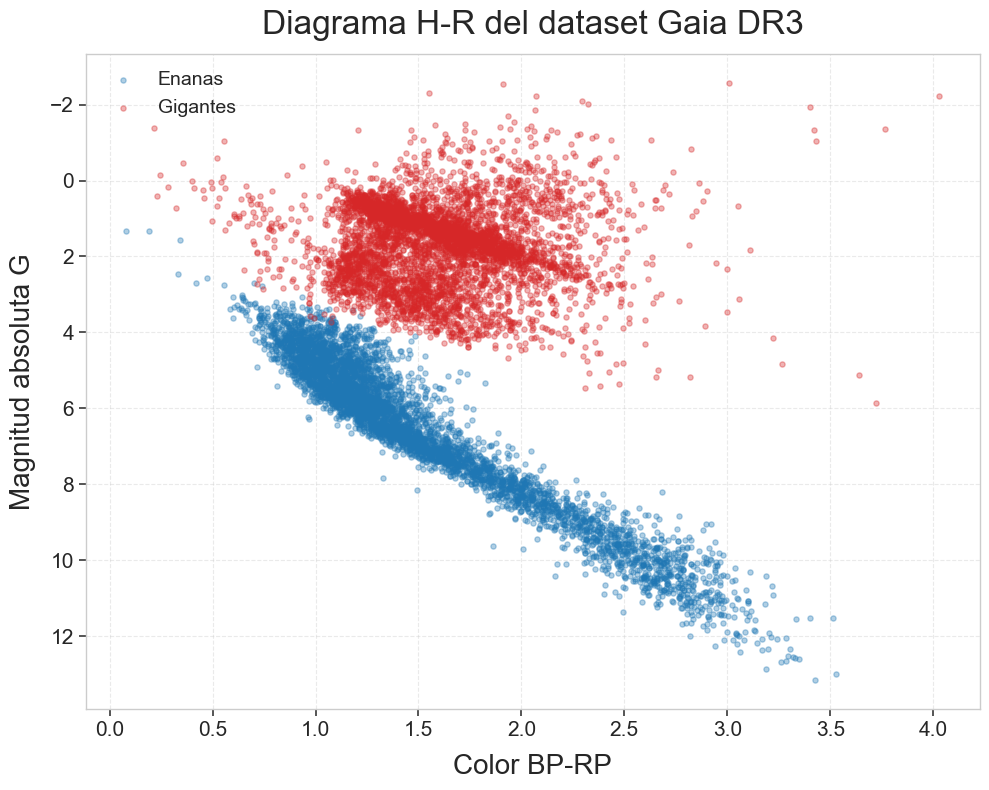

In [8]:
# Recalculo defensivo de magnitud absoluta si no existe en el CSV
if 'abs_mag_g' not in df.columns:
    if 'parallax' in df.columns and 'phot_g_mean_mag' in df.columns:
        # Evitar problemas numericos con paralaje no positiva
        df = df[df['parallax'] > 0].copy()
        df['abs_mag_g'] = df['phot_g_mean_mag'] + 5 + 5 * np.log10(df['parallax'] / 1000)
    else:
        raise ValueError('No se puede construir abs_mag_g: faltan columnas requeridas.')

plt.figure(figsize=(10, 8))
if 'clase_real' in df.columns:
    enanas = df[df['clase_real'] == 'Enana']
    gigantes = df[df['clase_real'] == 'Gigante']
    plt.scatter(enanas['bp_rp'], enanas['abs_mag_g'], s=14, c='#1f77b4', alpha=0.35, label='Enanas')
    plt.scatter(gigantes['bp_rp'], gigantes['abs_mag_g'], s=14, c='#d62728', alpha=0.35, label='Gigantes')
    plt.legend(fontsize=14)
else:
    plt.scatter(df['bp_rp'], df['abs_mag_g'], s=14, c='#1f77b4', alpha=0.35)

ax = plt.gca()
ax.invert_yaxis()
ax.set_title('Diagrama H-R del dataset Gaia DR3', fontsize=24, pad=14)
ax.set_xlabel('Color BP-RP', fontsize=20, labelpad=10)
ax.set_ylabel('Magnitud absoluta G', fontsize=20, labelpad=10)
ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Analisis multivariable

Se incluyen correlaciones lineales, dispersiones clave y resumen estadistico por clase para identificar separacion entre poblaciones.

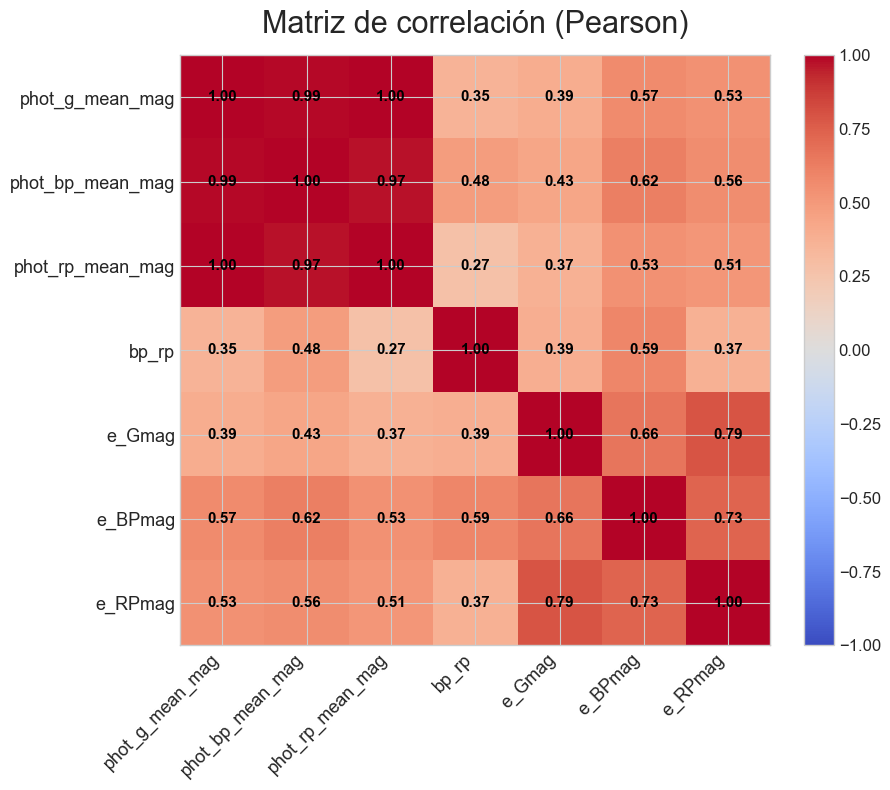

In [9]:
# Matriz de correlacion
corr_cols = predictoras
corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right', fontsize=13)
ax.set_yticklabels(corr.columns, fontsize=13)
ax.set_title('Matriz de correlación (Pearson)', fontsize=22, pad=16)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        valor = corr.iloc[i, j]
        ax.text(
            j,
            i,
            f'{valor:.2f}',
            ha='center',
            va='center',
            fontsize=11,
            color='black',
            fontweight='bold'
        )

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

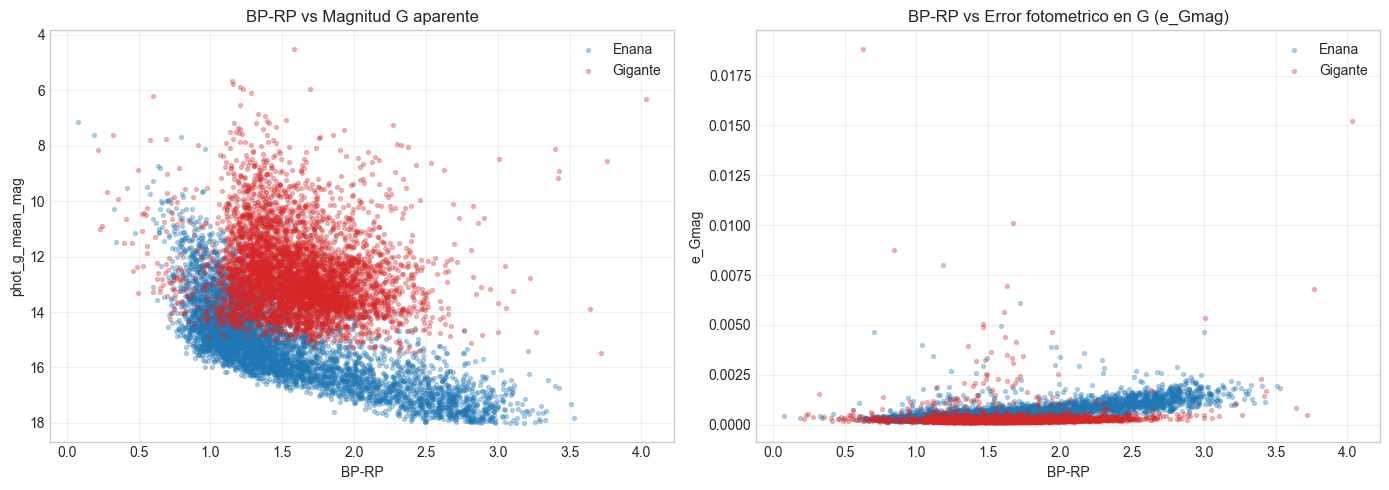

In [10]:
# Scatter multivariable: color vs magnitud y color vs error fotometrico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if 'clase_real' in df.columns:
    for clase, color in [('Enana', '#1f77b4'), ('Gigante', '#d62728')]:
        sub = df[df['clase_real'] == clase]
        axes[0].scatter(sub['bp_rp'], sub['phot_g_mean_mag'], s=8, alpha=0.3, label=clase, c=color)
        axes[1].scatter(sub['bp_rp'], sub['e_Gmag'], s=8, alpha=0.3, label=clase, c=color)
    axes[0].legend()
    axes[1].legend()
else:
    axes[0].scatter(df['bp_rp'], df['phot_g_mean_mag'], s=8, alpha=0.3, c='#1f77b4')
    axes[1].scatter(df['bp_rp'], df['e_Gmag'], s=8, alpha=0.3, c='#1f77b4')

axes[0].set_title('BP-RP vs Magnitud G aparente')
axes[0].set_xlabel('BP-RP')
axes[0].set_ylabel('phot_g_mean_mag')
axes[0].invert_yaxis()
axes[0].grid(alpha=0.3)

axes[1].set_title('BP-RP vs Error fotometrico en G (e_Gmag)')
axes[1].set_xlabel('BP-RP')
axes[1].set_ylabel('e_Gmag')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# Resumen por clase (media, mediana, desviacion)
if 'clase_real' in df.columns:
    resumen_clase = df.groupby('clase_real')[predictoras].agg(['mean', 'median', 'std']).round(4)
    display(resumen_clase)
else:
    print('No hay columna clase_real para resumen por clase.')

phot_g_mean_mag                  phot_bp_mean_mag                  phot_rp_mean_mag                    bp_rp                  \
                      mean   median     std             mean   median     std             mean   median     std    mean  median     std   
clase_real                                                                                                                                
Enana              15.1377  15.2412  1.5122          15.8720  15.8123  1.8047          14.3390  14.5024  1.3557  1.5331  1.3368  0.5859   
Gigante            12.5913  12.8633  1.4321          13.3568  13.6232  1.4900          11.7517  12.0323  1.4103  1.6050  1.5836  0.3607   

            e_Gmag                 e_BPmag                 e_RPmag                  
              mean  median     std    mean  median     std    mean  median     std  
clase_real                                                                          
Enana       0.0006  0.0004  0.0004  0.0076  0.0030  0.0117  0.0024  0.0017  0.0024  
Gigante     0.0003  0.0002  0.0005  0.0012  0.0009  0.0020  0.0007  0.0005  0.0014

In [12]:
from scipy import stats
print('Ejecutando pruebas estadísticas para comparar la distribución de bp_rp entre Enanas y Gigantes...')
# 1. Separar los datos en dos grupos independientes
color_enanas = df[df['clase_real'] == 'Enana']['bp_rp']
color_gigantes = df[df['clase_real'] == 'Gigante']['bp_rp']

# 2. Ejecutar el t-test
t_stat, p_val_t = stats.ttest_ind(color_enanas, color_gigantes, equal_var=False)

# 3. Ejecutar el test de Mann-Whitney
u_stat, p_val_mw = stats.mannwhitneyu(color_enanas, color_gigantes)

# 4. Ejecutar el test de Kolmogorov-Smirnov (KS)
ks_stat, p_val_ks = stats.ks_2samp(color_enanas, color_gigantes)

print(f"t-test p-value: {p_val_t}")
print(f"Mann-Whitney p-value: {p_val_mw}")
print(f"KS-test p-value: {p_val_ks}")

Ejecutando pruebas estadísticas para comparar la distribución de bp_rp entre Enanas y Gigantes...
t-test p-value: 1.541731218776788e-13
Mann-Whitney p-value: 4.463119989636953e-84
KS-test p-value: 3.265623175347582e-176


## PCA: Análisis dimensional de variables predictoras

Reducción dimensional con PCA (2 componentes) para comparar con UMAP. Incluye visualización 2D, análisis de correlaciones (loadings) y biplot de contribuciones.

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Preparar datos para PCA
predictoras_cols = [
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag',
    'bp_rp',
    'e_Gmag',
    'e_BPmag',
    'e_RPmag',
]

# Dataset sin valores ausentes
df_pca = df[predictoras_cols + ['clase_real']].dropna()
print(f'Filas para PCA: {len(df_pca):,}')
print(df_pca['clase_real'].value_counts())

# Normalizar
scaler_pca = StandardScaler()
X_pca_scaled = scaler_pca.fit_transform(df_pca[predictoras_cols])

# Aplicar PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_pca_scaled)

# DataFrame resultado
df_pca_result = pd.DataFrame({
    'PCA_1': X_pca[:, 0],
    'PCA_2': X_pca[:, 1],
    'clase_real': df_pca['clase_real'].values
})

print('\nExplained variance ratios:', pca.explained_variance_ratio_)


Filas para PCA: 10,000
Gigante    5000
Enana      5000
Name: clase_real, dtype: int64

Explained variance ratios: [0.64755705 0.18195233]


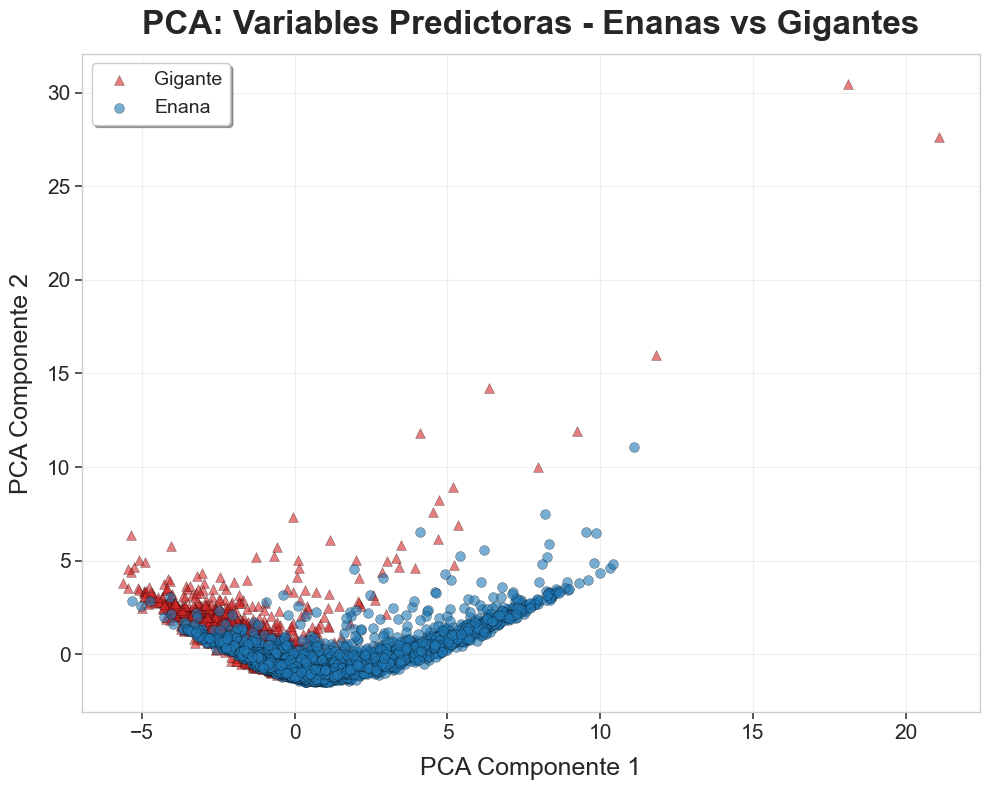


✓ Visualización PCA completada
  - Enanas: 5,000 puntos
  - Gigantes: 5,000 puntos


In [14]:
# 2. Visualización PCA 2D
colors = {'Enana': '#1f77b4', 'Gigante': '#d62728'}
markers = {'Enana': 'o', 'Gigante': '^'}
fig, ax = plt.subplots(figsize=(10, 8))
for clase in df_pca_result['clase_real'].unique():
    mask = df_pca_result['clase_real'] == clase
    ax.scatter(
        df_pca_result.loc[mask, 'PCA_1'],
        df_pca_result.loc[mask, 'PCA_2'],
        label=clase,
        alpha=0.6,
        s=50,
        color=colors.get(clase, '#1f77b4'),
        marker=markers.get(clase, 'o'),
        edgecolors='black',
        linewidth=0.3
    )

ax.set_xlabel('PCA Componente 1', fontsize=18, labelpad=10)
ax.set_ylabel('PCA Componente 2', fontsize=18, labelpad=10)
ax.set_title('PCA: Variables Predictoras - Enanas vs Gigantes', fontsize=24, fontweight='bold', pad=14)
ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
ax.legend(loc='best', fontsize=14, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\n✓ Visualización PCA completada')
print(f'  - Enanas: {(df_pca_result["clase_real"] == "Enana").sum():,} puntos')
print(f'  - Gigantes: {(df_pca_result["clase_real"] == "Gigante").sum():,} puntos')


Correlación entre variables originales y componentes PCA:
                   PCA_1   PCA_2
phot_g_mean_mag   0.8907 -0.4528
phot_bp_mean_mag  0.9225 -0.3727
phot_rp_mean_mag  0.8631 -0.4960
bp_rp             0.5797  0.3377
e_Gmag            0.6995  0.5428
e_BPmag           0.8288  0.3458
e_RPmag           0.7947  0.3941


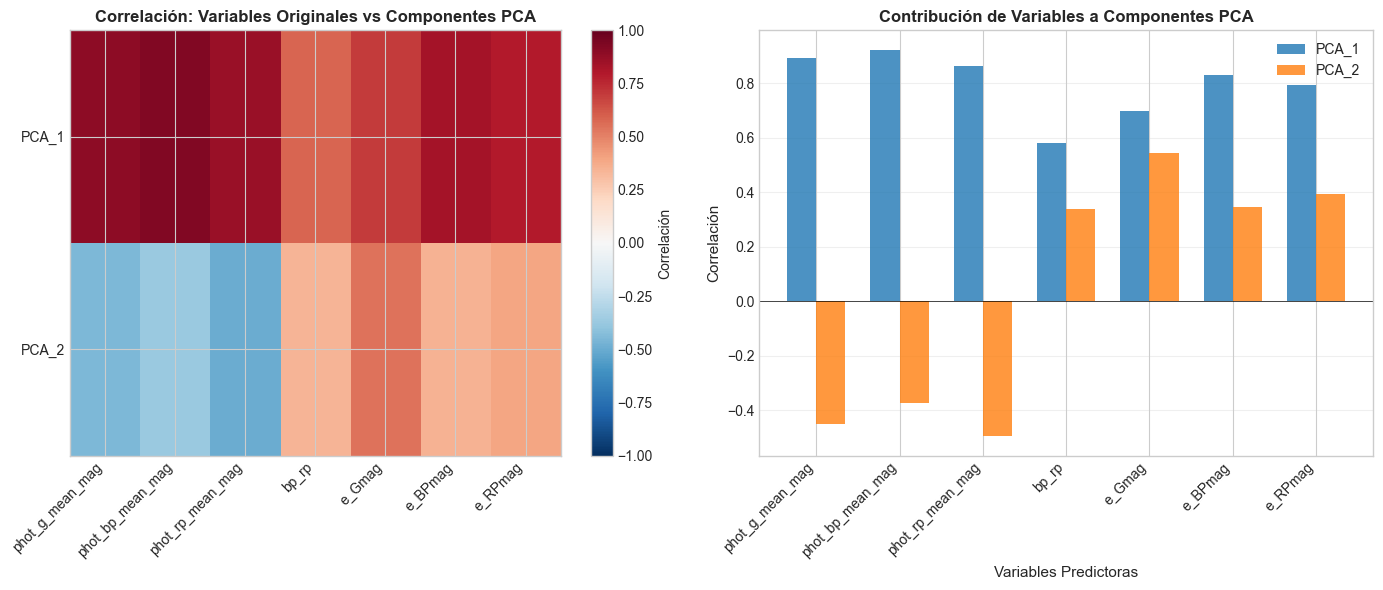

In [15]:
# 3. Análisis de contribución: correlación entre variables originales y componentes PCA
correlations_pca = pd.DataFrame(
    np.corrcoef(X_pca_scaled.T, X_pca.T)[-2:, :-2].T,
    columns=['PCA_1', 'PCA_2'],
    index=predictoras_cols
)

print('\nCorrelación entre variables originales y componentes PCA:')
print(correlations_pca.round(4))

# Visualizaciones de correlaciones
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
im = axes[0].imshow(correlations_pca.T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
axes[0].set_xticks(range(len(correlations_pca.index)))
axes[0].set_xticklabels(correlations_pca.index, rotation=45, ha='right')
axes[0].set_yticks(range(2))
axes[0].set_yticklabels(['PCA_1', 'PCA_2'])
axes[0].set_title('Correlación: Variables Originales vs Componentes PCA', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[0], label='Correlación')

x = np.arange(len(predictoras_cols))
width = 0.35
bars1 = axes[1].bar(x - width/2, correlations_pca['PCA_1'], width, label='PCA_1', alpha=0.8, color='#1f77b4')
bars2 = axes[1].bar(x + width/2, correlations_pca['PCA_2'], width, label='PCA_2', alpha=0.8, color='#ff7f0e')
axes[1].set_xlabel('Variables Predictoras', fontsize=11)
axes[1].set_ylabel('Correlación', fontsize=11)
axes[1].set_title('Contribución de Variables a Componentes PCA', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(predictoras_cols, rotation=45, ha='right')
axes[1].legend(fontsize=10)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
axes[1].grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



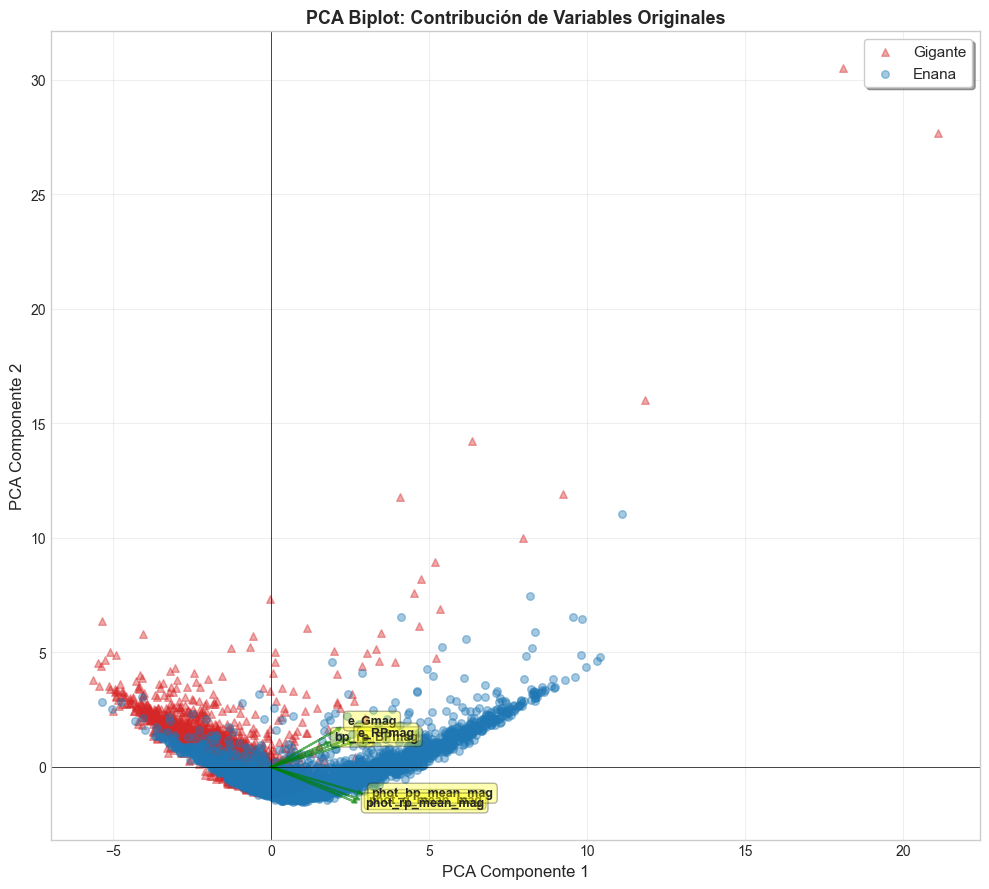

In [16]:
# 4. Biplot PCA: flechas de contribución de variables
fig, ax = plt.subplots(figsize=(10, 9))

# puntos PCA
for clase in df_pca_result['clase_real'].unique():
    mask = df_pca_result['clase_real'] == clase
    ax.scatter(
        df_pca_result.loc[mask, 'PCA_1'],
        df_pca_result.loc[mask, 'PCA_2'],
        label=clase,
        alpha=0.4,
        s=30,
        color=colors.get(clase, '#1f77b4'),
        marker=markers.get(clase, 'o')
    )

# flechas basadas en correlaciones_pca
scale_factor = 3.0
for i, var in enumerate(predictoras_cols):
    ax.arrow(
        0, 0,
        correlations_pca.loc[var, 'PCA_1'] * scale_factor,
        correlations_pca.loc[var, 'PCA_2'] * scale_factor,
        head_width=0.15,
        head_length=0.15,
        fc='green',
        ec='green',
        alpha=0.6,
        linewidth=1.5
    )
    ax.text(
        correlations_pca.loc[var, 'PCA_1'] * scale_factor * 1.15,
        correlations_pca.loc[var, 'PCA_2'] * scale_factor * 1.15,
        var,
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
    )

ax.set_xlabel('PCA Componente 1', fontsize=12)
ax.set_ylabel('PCA Componente 2', fontsize=12)
ax.set_title('PCA Biplot: Contribución de Variables Originales', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()



In [17]:
# 5. Interpretación técnica PCA

print('INTERPRETACIÓN PCA')

print('\nExplained variance ratio por componente:')
print(pca.explained_variance_ratio_)

print('\nVARIABLES MÁS INFLUYENTES EN PCA_1:')
for var, val in correlations_pca['PCA_1'].abs().sort_values(ascending=False).head(4).items():
    actual = correlations_pca.loc[var, 'PCA_1']
    sign = 'POS' if actual>0 else 'NEG'
    print(f'  {sign} {var}: {actual:+.4f}')

print('\nVARIABLES MÁS INFLUYENTES EN PCA_2:')
for var, val in correlations_pca['PCA_2'].abs().sort_values(ascending=False).head(4).items():
    actual = correlations_pca.loc[var, 'PCA_2']
    sign = 'POS' if actual>0 else 'NEG'
    print(f'  {sign} {var}: {actual:+.4f}')

enanas_mean = df_pca_result[df_pca_result['clase_real']=='Enana'][['PCA_1','PCA_2']].mean()
gigantes_mean = df_pca_result[df_pca_result['clase_real']=='Gigante'][['PCA_1','PCA_2']].mean()
diff = gigantes_mean - enanas_mean
print('\nDIFERENCIA DE MEDIAS (Gigantes - Enanas):')
print(diff)


INTERPRETACIÓN PCA

Explained variance ratio por componente:
[0.64755705 0.18195233]

VARIABLES MÁS INFLUYENTES EN PCA_1:
  POS phot_bp_mean_mag: +0.9225
  POS phot_g_mean_mag: +0.8907
  POS phot_rp_mean_mag: +0.8631
  POS e_BPmag: +0.8288

VARIABLES MÁS INFLUYENTES EN PCA_2:
  POS e_Gmag: +0.5428
  NEG phot_rp_mean_mag: -0.4960
  NEG phot_g_mean_mag: -0.4528
  POS e_RPmag: +0.3941

DIFERENCIA DE MEDIAS (Gigantes - Enanas):
PCA_1   -2.384028
PCA_2    0.753578
dtype: float64


## UMAP: Análisis dimensional de variables predictoras

Reducción dimensional con UMAP para visualizar las enanas y gigantes en 2D, y análisis de contribución de las variables originales a estos componentes.

In [18]:
from sklearn.preprocessing import StandardScaler
from umap import UMAP
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# 1. Preparar datos para UMAP
predictoras_cols = [
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag',
    'bp_rp',
    'e_Gmag',
    'e_BPmag',
    'e_RPmag',
]

# Crear dataset sin valores ausentes
df_umap = df[predictoras_cols + ['clase_real']].dropna()
print(f'Filas para UMAP: {len(df_umap):,}')
print(f'Distribución de clases:')
print(df_umap['clase_real'].value_counts())

# Normalizar las variables predictoras
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_umap[predictoras_cols])

# 2. Aplicar UMAP con 2 componentes
umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, metric='euclidean')
X_umap = umap_model.fit_transform(X_scaled)

# Crear DataFrame con resultados UMAP
df_umap_result = pd.DataFrame({
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1],
    'clase_real': df_umap['clase_real'].values
})

print(f'\nComponentes UMAP creados:')
print(df_umap_result.describe())


c:\Users\igtop\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filas para UMAP: 10,000
Distribución de clases:
Gigante    5000
Enana      5000
Name: clase_real, dtype: int64

Componentes UMAP creados:
             UMAP_1        UMAP_2
count  10000.000000  10000.000000
mean       4.593071      6.875139
std        5.744887      4.239238
min       -6.018091     -2.288844
25%       -1.324120      3.969484
50%        5.229424      6.989342
75%       10.116507     10.060074
max       13.497687     15.487541


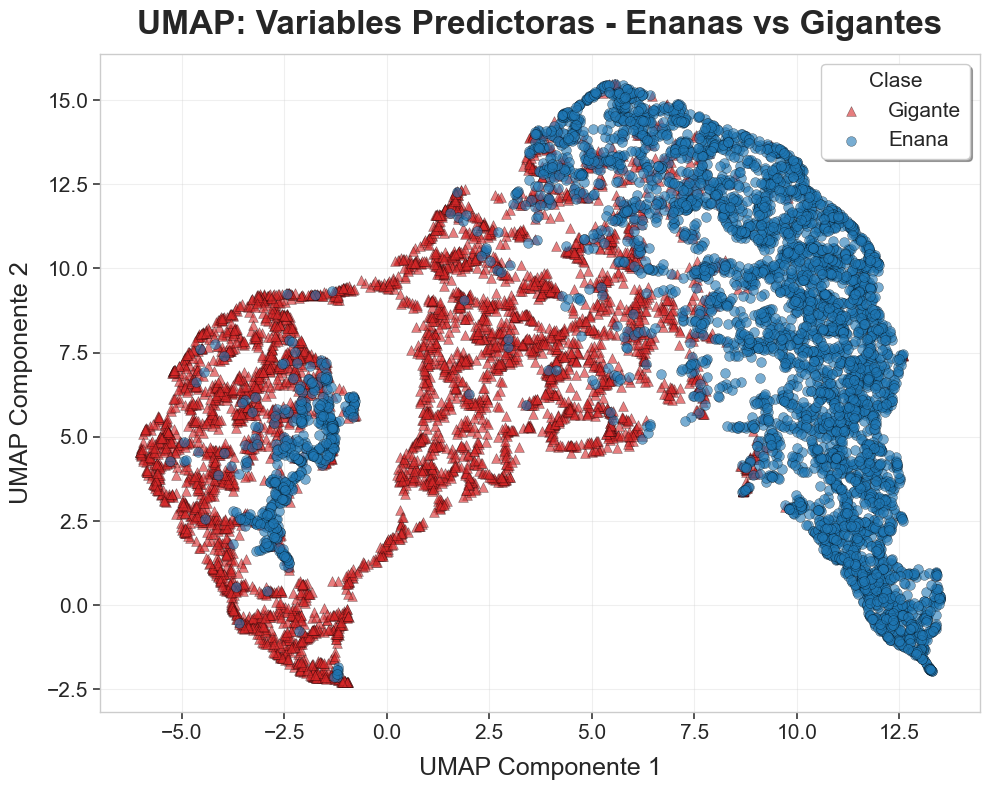

In [19]:
# 3. Visualización UMAP con diferenciación entre Enanas y Gigantes
fig, ax = plt.subplots(figsize=(10, 8))

# Colores para las clases
colors = {'Enana': '#1f77b4', 'Gigante': '#d62728'}
markers = {'Enana': 'o', 'Gigante': '^'}

for clase in df_umap_result['clase_real'].unique():
    mask = df_umap_result['clase_real'] == clase
    ax.scatter(
        df_umap_result.loc[mask, 'UMAP_1'],
        df_umap_result.loc[mask, 'UMAP_2'],
        label=clase,
        alpha=0.6,
        s=50,
        color=colors.get(clase, '#1f77b4'),
        marker=markers.get(clase, 'o'),
        edgecolors='black',
        linewidth=0.3
    )

ax.set_xlabel('UMAP Componente 1', fontsize=18, labelpad=10)
ax.set_ylabel('UMAP Componente 2', fontsize=18, labelpad=10)
ax.set_title('UMAP: Variables Predictoras - Enanas vs Gigantes', fontsize=24, fontweight='bold', pad=14)
ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
ax.legend(loc='best', fontsize=15, frameon=True, shadow=True, title='Clase', title_fontsize=15)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [20]:
# 4. Análisis de contribución: Correlación entre variables originales y componentes UMAP
print('ANÁLISIS DE CONTRIBUCIÓN: Cómo se conforman los componentes UMAP')

# Calcular correlaciones entre las variables originales y los componentes UMAP
correlations = pd.DataFrame(
    np.corrcoef(X_scaled.T, X_umap.T)[-2:, :-2].T,
    columns=['UMAP_1', 'UMAP_2'],
    index=predictoras_cols
)

print('\nCorrelación entre variables originales y componentes UMAP:')
print(correlations.round(4))

# Identificar variables más importantes para cada componente
print('\n\nVARIABLES MÁS INFLUYENTES:')
for i, col in enumerate(['UMAP_1', 'UMAP_2']):
    top_pos = correlations[col].nlargest(3)
    top_neg = correlations[col].nsmallest(3)
    print(f'\n{col}:')
    print(f'  Correlaciones POSITIVAS más fuertes:')
    for var, corr in top_pos.items():
        print(f'    {var}: {corr:.4f}')
    print(f'  Correlaciones NEGATIVAS más fuertes:')
    for var, corr in top_neg.items():
        print(f'    {var}: {corr:.4f}')


ANÁLISIS DE CONTRIBUCIÓN: Cómo se conforman los componentes UMAP

Correlación entre variables originales y componentes UMAP:
                  UMAP_1  UMAP_2
phot_g_mean_mag   0.8848  0.1567
phot_bp_mean_mag  0.8658  0.0660
phot_rp_mean_mag  0.8888  0.2113
bp_rp             0.2385 -0.5394
e_Gmag            0.4153 -0.3463
e_BPmag           0.4829 -0.4346
e_RPmag           0.5556 -0.3173


VARIABLES MÁS INFLUYENTES:

UMAP_1:
  Correlaciones POSITIVAS más fuertes:
    phot_rp_mean_mag: 0.8888
    phot_g_mean_mag: 0.8848
    phot_bp_mean_mag: 0.8658
  Correlaciones NEGATIVAS más fuertes:
    bp_rp: 0.2385
    e_Gmag: 0.4153
    e_BPmag: 0.4829

UMAP_2:
  Correlaciones POSITIVAS más fuertes:
    phot_rp_mean_mag: 0.2113
    phot_g_mean_mag: 0.1567
    phot_bp_mean_mag: 0.0660
  Correlaciones NEGATIVAS más fuertes:
    bp_rp: -0.5394
    e_BPmag: -0.4346
    e_Gmag: -0.3463


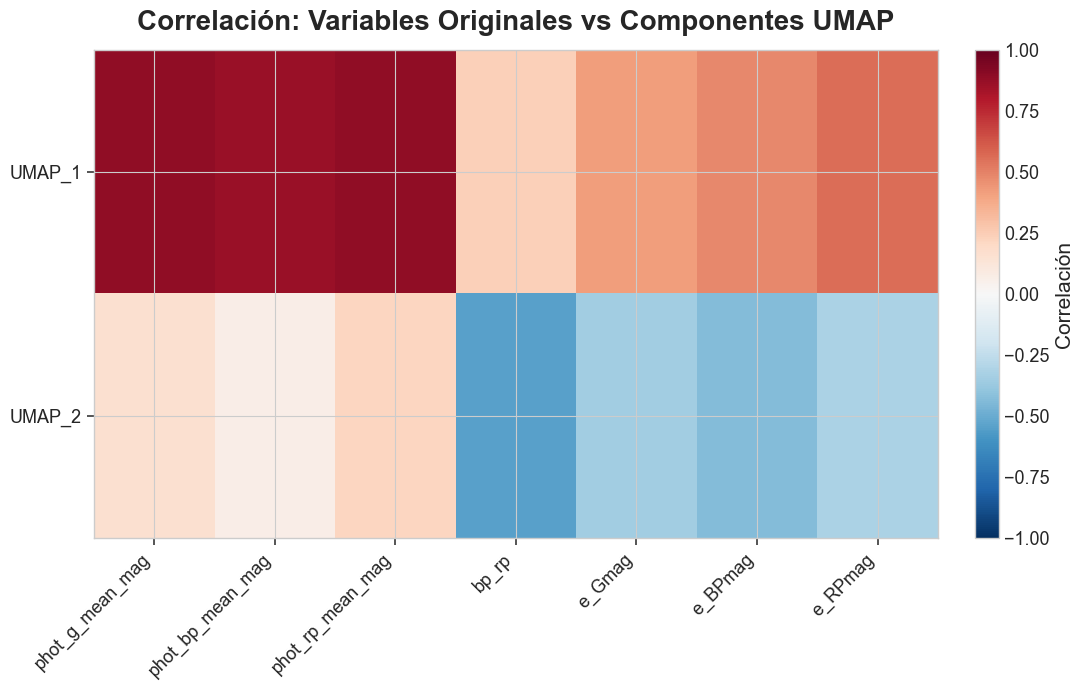

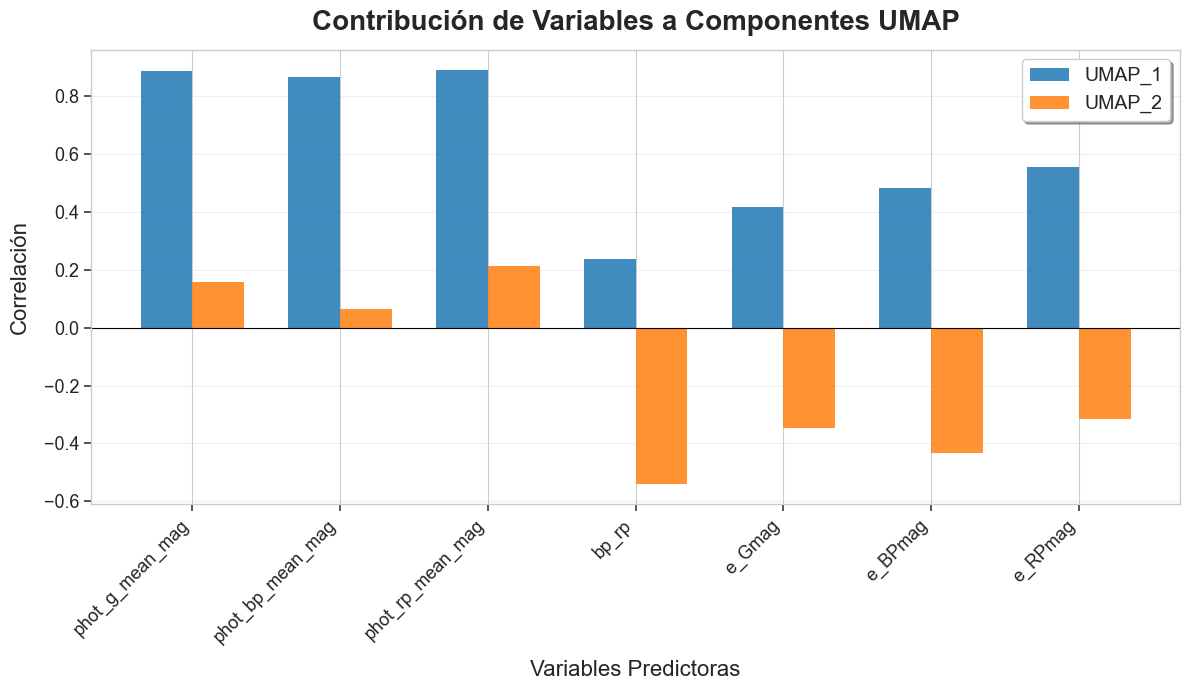

In [21]:
# 5. Visualización de las correlaciones (loadings plot)

# Figura 1: Heatmap de correlaciones
fig1, ax1 = plt.subplots(figsize=(11, 7))
im = ax1.imshow(correlations.T, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

ax1.set_xticks(range(len(correlations.index)))
ax1.set_xticklabels(correlations.index, rotation=45, ha='right', fontsize=13)
ax1.set_yticks(range(2))
ax1.set_yticklabels(['UMAP_1', 'UMAP_2'], fontsize=14)
ax1.set_title('Correlación: Variables Originales vs Componentes UMAP', fontsize=20, fontweight='bold', pad=14)
ax1.tick_params(axis='both', labelsize=13, width=1.1, length=5)

cbar = fig1.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.set_label('Correlación', fontsize=15)
cbar.ax.tick_params(labelsize=13)

plt.tight_layout()
plt.show()

# Figura 2: Gráfico de barras con correlaciones
fig2, ax2 = plt.subplots(figsize=(12, 7))
x = np.arange(len(predictoras_cols))
width = 0.35
bars1 = ax2.bar(x - width/2, correlations['UMAP_1'], width, label='UMAP_1', alpha=0.85, color='#1f77b4')
bars2 = ax2.bar(x + width/2, correlations['UMAP_2'], width, label='UMAP_2', alpha=0.85, color='#ff7f0e')

ax2.set_xlabel('Variables Predictoras', fontsize=16, labelpad=10)
ax2.set_ylabel('Correlación', fontsize=16, labelpad=10)
ax2.set_title('Contribución de Variables a Componentes UMAP', fontsize=20, fontweight='bold', pad=14)
ax2.set_xticks(x)
ax2.set_xticklabels(predictoras_cols, rotation=45, ha='right', fontsize=13)
ax2.tick_params(axis='both', labelsize=13, width=1.1, length=5)
ax2.legend(fontsize=14, frameon=True, shadow=True)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


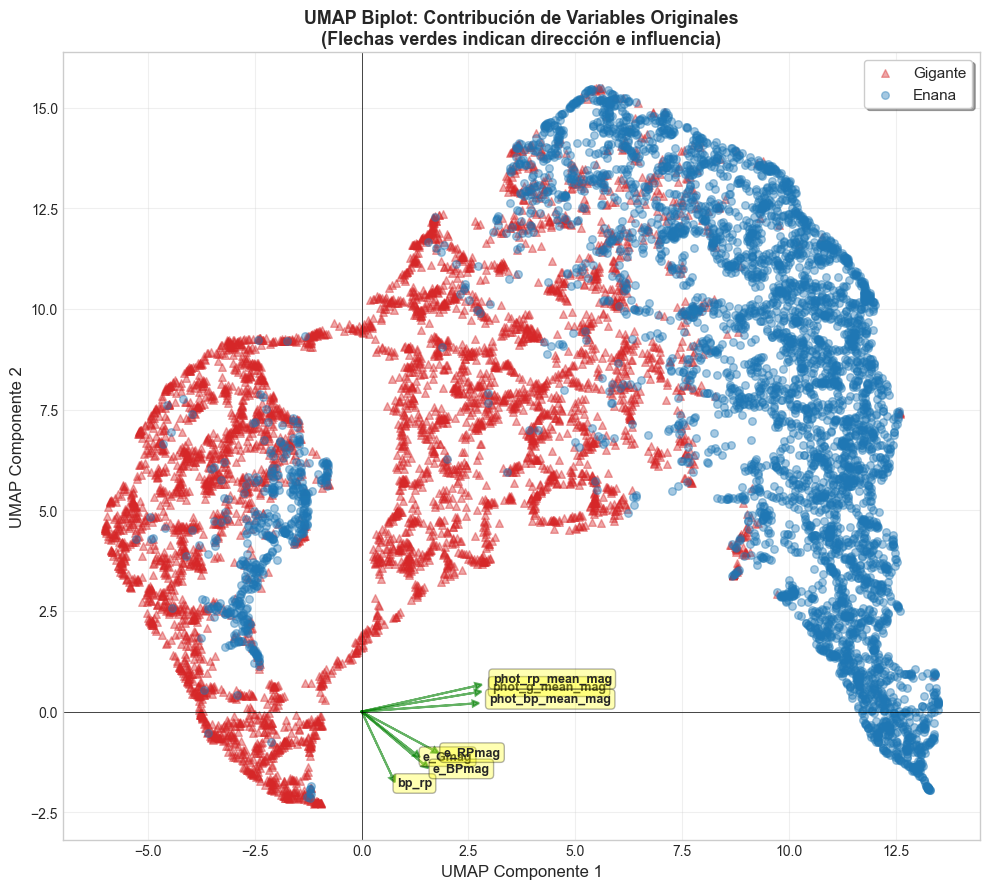

In [22]:
# 6. Biplot estilo: flecha de contribución de variables
fig, ax = plt.subplots(figsize=(10, 9))

# Plotear los puntos UMAP coloreados por clase
for clase in df_umap_result['clase_real'].unique():
    mask = df_umap_result['clase_real'] == clase
    ax.scatter(
        df_umap_result.loc[mask, 'UMAP_1'],
        df_umap_result.loc[mask, 'UMAP_2'],
        label=clase,
        alpha=0.4,
        s=30,
        color=colors.get(clase, '#1f77b4'),
        marker=markers.get(clase, 'o')
    )

# Añadir flechas que muestran la dirección de las variables originales
# Escalamos las correlaciones para hacerlas visibles
scale_factor = 3.0
for i, var in enumerate(predictoras_cols):
    ax.arrow(
        0, 0,
        correlations.loc[var, 'UMAP_1'] * scale_factor,
        correlations.loc[var, 'UMAP_2'] * scale_factor,
        head_width=0.15,
        head_length=0.15,
        fc='green',
        ec='green',
        alpha=0.6,
        linewidth=1.5
    )
    
    # Etiqueta al final de cada flecha
    ax.text(
        correlations.loc[var, 'UMAP_1'] * scale_factor * 1.15,
        correlations.loc[var, 'UMAP_2'] * scale_factor * 1.15,
        var,
        fontsize=9,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3)
    )

ax.set_xlabel('UMAP Componente 1', fontsize=12)
ax.set_ylabel('UMAP Componente 2', fontsize=12)
ax.set_title('UMAP Biplot: Contribución de Variables Originales\n(Flechas verdes indican dirección e influencia)', 
             fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, frameon=True, shadow=True)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='k', linewidth=0.5)
ax.axvline(x=0, color='k', linewidth=0.5)
plt.tight_layout()
plt.show()



In [23]:
# 7. Interpretación técnica 
print('INTERPRETACIÓN TÉCNICA')


print('\nCOMPONENTE UMAP_1 (Eje Horizontal):')
comp1_analysis = correlations['UMAP_1'].abs().sort_values(ascending=False)
print(f'Variables más importantes (por valor absoluto):')
for var, corr_abs in comp1_analysis.head(4).items():
    actual_corr = correlations.loc[var, 'UMAP_1']
    direction = 'POS' if actual_corr > 0 else 'NEG'
    print(f'  {direction} {var}: {actual_corr:+.4f}')

print('\nCOMPONENTE UMAP_2 (Eje Vertical):')
comp2_analysis = correlations['UMAP_2'].abs().sort_values(ascending=False)
print(f'Variables más importantes (por valor absoluto):')
for var, corr_abs in comp2_analysis.head(4).items():
    actual_corr = correlations.loc[var, 'UMAP_2']
    direction = 'POS' if actual_corr > 0 else 'NEG'
    print(f'  {direction} {var}: {actual_corr:+.4f}')

print('\nSEPARACIÓN DE CLASES:')
print(f'La separación entre Enanas y Gigantes es principalmente impulsada por:')
# Calcular diferencia de medias en el espacio UMAP
enanas_mean = df_umap_result[df_umap_result['clase_real'] == 'Enana'][['UMAP_1', 'UMAP_2']].mean()
gigantes_mean = df_umap_result[df_umap_result['clase_real'] == 'Gigante'][['UMAP_1', 'UMAP_2']].mean()
diff = gigantes_mean - enanas_mean
dir1 = '(derecha)' if diff["UMAP_1"] > 0 else '(izquierda)'
dir2 = '(arriba)' if diff["UMAP_2"] > 0 else '(abajo)'
print(f'  - Diferencia UMAP_1: {diff["UMAP_1"]:+.4f} - Gigantes {dir1}')
print(f'  - Diferencia UMAP_2: {diff["UMAP_2"]:+.4f} - Gigantes {dir2}')



INTERPRETACIÓN TÉCNICA

COMPONENTE UMAP_1 (Eje Horizontal):
Variables más importantes (por valor absoluto):
  POS phot_rp_mean_mag: +0.8888
  POS phot_g_mean_mag: +0.8848
  POS phot_bp_mean_mag: +0.8658
  POS e_RPmag: +0.5556

COMPONENTE UMAP_2 (Eje Vertical):
Variables más importantes (por valor absoluto):
  NEG bp_rp: -0.5394
  NEG e_BPmag: -0.4346
  NEG e_Gmag: -0.3463
  NEG e_RPmag: -0.3173

SEPARACIÓN DE CLASES:
La separación entre Enanas y Gigantes es principalmente impulsada por:
  - Diferencia UMAP_1: -8.1693 - Gigantes (izquierda)
  - Diferencia UMAP_2: -1.0891 - Gigantes (abajo)


## 7. Export para modelado

Se guarda una tabla minimalista con predictores y etiqueta para entrenamiento posterior fuera de este notebook.

In [24]:
cols_export = predictoras + (['clase_real'] if 'clase_real' in df.columns else [])
df_modelado = df[cols_export].copy()
df_modelado.to_csv('dataset_predictoras_v1.csv', index=False)
print('Archivo exportado: dataset_predictoras_v1.csv')
df_modelado.head()

Archivo exportado: dataset_predictoras_v1.csv


,phot_g_mean_mag,phot_bp_mean_mag,phot_rp_mean_mag,bp_rp,e_Gmag,e_BPmag,e_RPmag,clase_real
0,14.544000,15.594014,13.535884,2.058130,0.000204,0.001157,0.000552,Gigante
1,16.988377,18.471436,15.789686,2.681749,0.001056,0.021177,0.003108,Enana
2,14.827709,15.348033,14.138805,1.209228,0.000366,0.005205,0.000907,Enana
3,15.269318,15.915274,14.483748,1.431525,0.000363,0.003135,0.001962,Enana
4,16.943250,17.795677,16.033890,1.761787,0.000780,0.010454,0.005876,Enana


## 8. Modelado supervisado para clasificación

Se entrenan varios clasificadores con split 75/25 usando las variables fotometricas predictoras y se comparan métricas para seleccionar el mejor modelo base.

,modelo,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc
0,GradientBoosting,0.9368,0.9368,0.9368,0.9368,0.9852
1,SVM_RBF,0.9336,0.9340,0.9336,0.9336,0.9819
2,RandomForest,0.9328,0.9330,0.9328,0.9328,0.9852
3,KNN,0.9308,0.9310,0.9308,0.9308,0.9793
4,ExtraTrees,0.9300,0.9301,0.9300,0.9300,0.9846
5,LogisticRegression,0.8992,0.8992,0.8992,0.8992,0.9627


Train: 7500 filas | Test: 2500 filas (split 75/25)
Mejor modelo por F1 weighted: GradientBoosting

Classification report (mejor modelo):
              precision    recall  f1-score   support

       Enana       0.93      0.94      0.94      1250
     Gigante       0.94      0.93      0.94      1250

    accuracy                           0.94      2500
   macro avg       0.94      0.94      0.94      2500
weighted avg       0.94      0.94      0.94      2500



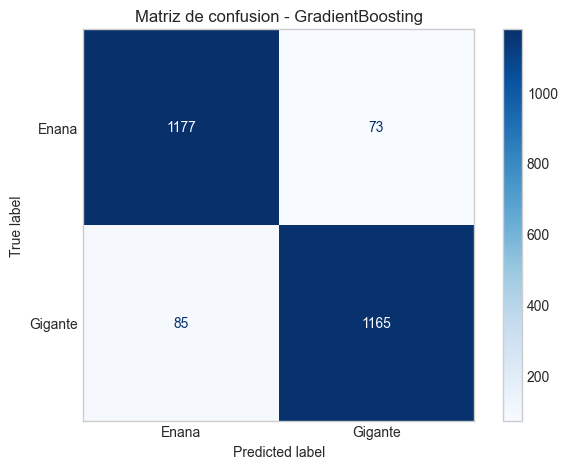

In [25]:
try:
    from sklearn.model_selection import train_test_split
except ImportError:
    get_ipython().run_line_magic('pip', 'install -q scikit-learn')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, roc_auc_score,
    classification_report, ConfusionMatrixDisplay

)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

if 'clase_real' not in df.columns:
    raise ValueError('No existe la columna objetivo clase_real en el dataset.')

# Dataset para modelado (solo filas completas para predictoras + etiqueta)
model_df = df[predictoras + ['clase_real']].dropna().copy()
X = model_df[predictoras]
y = model_df['clase_real']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)
is_binary = len(le.classes_) == 2

modelos = {
    'LogisticRegression': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=500, random_state=42))
    ]),
    'RandomForest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', RandomForestClassifier(n_estimators=400, random_state=42, class_weight='balanced_subsample'))
    ]),
    'SVM_RBF': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', C=2.0, probability=True, random_state=42))
    ]),
    'KNN': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=9, weights='distance'))
    ]),
    'GradientBoosting': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', GradientBoostingClassifier(random_state=42))
    ]),
    'ExtraTrees': Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', ExtraTreesClassifier(n_estimators=400, random_state=42, class_weight='balanced'))
    ])
}

resultados = []
fitted_models = {}

for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_pred_enc = le.transform(y_pred)

    precision_w, recall_w, f1_w, _ = precision_recall_fscore_support(
        y_test_enc, y_pred_enc, average='weighted', zero_division=0
    )

    roc_auc = np.nan
    if is_binary:
        y_score = None
        if hasattr(modelo, 'predict_proba'):
            y_score = modelo.predict_proba(X_test)[:, 1]
        elif hasattr(modelo, 'decision_function'):
            y_score = modelo.decision_function(X_test)
        if y_score is not None:
            roc_auc = roc_auc_score(y_test_enc, y_score)

    resultados.append({
        'modelo': nombre,
        'accuracy': accuracy_score(y_test_enc, y_pred_enc),
        'precision_weighted': precision_w,
        'recall_weighted': recall_w,
        'f1_weighted': f1_w,
        'roc_auc': roc_auc
    })

    fitted_models[nombre] = modelo

metricas_df = pd.DataFrame(resultados).sort_values('f1_weighted', ascending=False).reset_index(drop=True)
display(metricas_df.style.format({
    'accuracy': '{:.4f}',
    'precision_weighted': '{:.4f}',
    'recall_weighted': '{:.4f}',
    'f1_weighted': '{:.4f}',
    'roc_auc': '{:.4f}'
}))

print(f'Train: {X_train.shape[0]} filas | Test: {X_test.shape[0]} filas (split 75/25)')
mejor_modelo_nombre = metricas_df.loc[0, 'modelo']
mejor_modelo = fitted_models[mejor_modelo_nombre]
print(f'Mejor modelo por F1 weighted: {mejor_modelo_nombre}')

print('\nClassification report (mejor modelo):')
print(classification_report(y_test, mejor_modelo.predict(X_test), zero_division=0))

ConfusionMatrixDisplay.from_estimator(mejor_modelo, X_test, y_test, cmap='Blues')
plt.title(f'Matriz de confusion - {mejor_modelo_nombre}')
plt.grid(False)
plt.tight_layout()
plt.show()

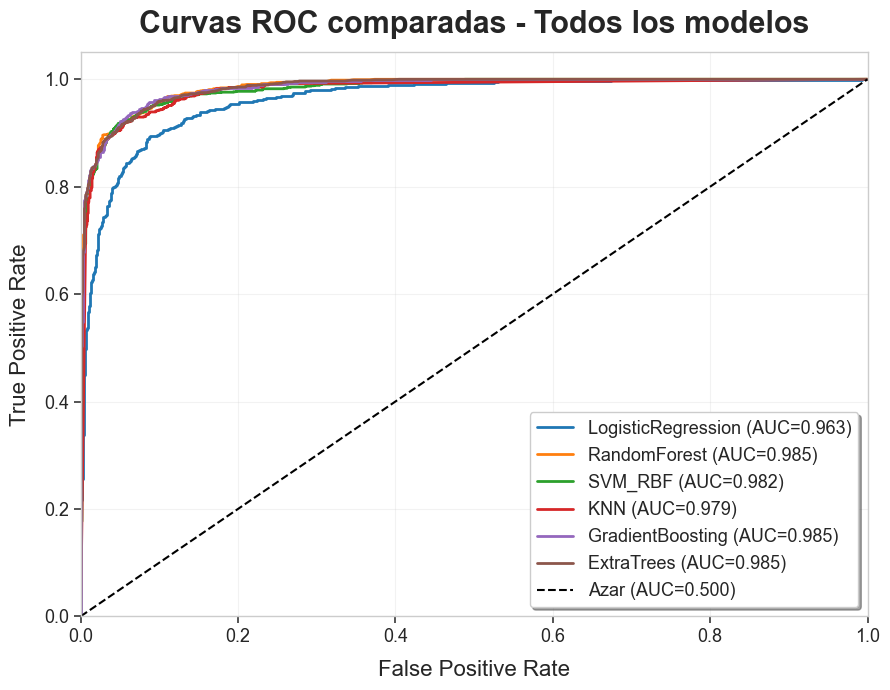

Curvas ROC trazadas: 6


In [26]:
# CURVAS ROC COMPARADAS: ROC de todos los modelos juntos
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))
curvas_trazadas = 0

for nombre, modelo in fitted_models.items():
    y_score = None

    if hasattr(modelo, 'predict_proba'):
        proba = modelo.predict_proba(X_test)
        # Caso binario: probabilidad de la clase positiva
        if proba.ndim == 2 and proba.shape[1] >= 2:
            y_score = proba[:, 1]
    elif hasattr(modelo, 'decision_function'):
        decision = modelo.decision_function(X_test)
        if np.ndim(decision) == 1:
            # Normalizacion para facilitar comparacion visual
            dmin, dmax = decision.min(), decision.max()
            y_score = (decision - dmin) / (dmax - dmin + 1e-12)

    if y_score is not None:
        fpr, tpr, _ = roc_curve(y_test_enc, y_score)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linewidth=2, label=f'{nombre} (AUC={roc_auc:.3f})')
        curvas_trazadas += 1

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Azar (AUC=0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16, labelpad=10)
plt.ylabel('True Positive Rate', fontsize=16, labelpad=10)
plt.title('Curvas ROC comparadas - Todos los modelos', fontsize=22, fontweight='bold', pad=14)
plt.legend(loc='lower right', fontsize=13, frameon=True, shadow=True)
plt.tick_params(axis='both', labelsize=13, width=1.1, length=5)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f'Curvas ROC trazadas: {curvas_trazadas}')

### 8.1 Ajuste de hiperparametros, validacion cruzada y persistencia del modelo

En esta seccion se afina el mejor modelo con `RandomizedSearchCV`, se reportan metricas con validacion cruzada estratificada y se guarda el modelo final para inferencia futura.

Mejores hiperparametros encontrados:
{'clf__learning_rate': 0.012184186502221762, 'clf__max_depth': 5, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 763, 'clf__subsample': 0.8603553891795411}
Mejor score CV interno (train split): 0.9316


,metrica,media,std
0,accuracy,0.9337,0.0055
1,precision_weighted,0.9337,0.0055
2,recall_weighted,0.9337,0.0055
3,f1_weighted,0.9337,0.0055
4,roc_auc_ovr_weighted,0.9848,0.0008



Classification report (modelo ajustado):
              precision    recall  f1-score   support

       Enana       0.93      0.94      0.93      1250
     Gigante       0.94      0.93      0.93      1250

    accuracy                           0.93      2500
   macro avg       0.93      0.93      0.93      2500
weighted avg       0.93      0.93      0.93      2500



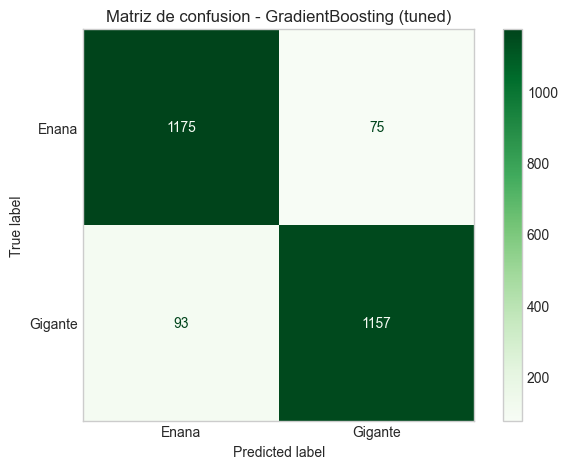

Modelo final guardado en: modelo_clasificacion_estelar.joblib


In [20]:
# Dependencias para tuning, validacion cruzada y guardado
try:
    import joblib
except ImportError:
    get_ipython().run_line_magic('pip', 'install -q joblib')
    import joblib

from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from scipy.stats import randint, uniform, loguniform

# Evitar errores de paralelizacion de joblib en algunos entornos Windows
N_JOBS_SAFE = 1

# Espacios de busqueda para cada candidato
search_spaces = {
    'LogisticRegression': {
        'clf__C': loguniform(1e-3, 1e2),
        'clf__penalty': ['l2'],
        'clf__solver': ['lbfgs', 'liblinear']
    },
    'RandomForest': {
        'clf__n_estimators': randint(200, 900),
        'clf__max_depth': randint(3, 30),
        'clf__min_samples_split': randint(2, 20),
        'clf__min_samples_leaf': randint(1, 10),
        'clf__max_features': ['sqrt', 'log2', None]
    },
    'SVM_RBF': {
        'clf__C': loguniform(1e-2, 1e2),
        'clf__gamma': loguniform(1e-4, 1e0),
        'clf__kernel': ['rbf']
    },
    'KNN': {
        'clf__n_neighbors': randint(3, 31),
        'clf__weights': ['uniform', 'distance'],
        'clf__p': [1, 2]
    },
    'GradientBoosting': {
        'clf__n_estimators': randint(100, 800),
        'clf__learning_rate': loguniform(1e-2, 3e-1),
        'clf__max_depth': randint(2, 6),
        'clf__subsample': uniform(0.6, 0.4),
        'clf__min_samples_split': randint(2, 20),
        'clf__min_samples_leaf': randint(1, 10)
    },
    'ExtraTrees': {
        'clf__n_estimators': randint(200, 1000),
        'clf__max_depth': randint(3, 35),
        'clf__min_samples_split': randint(2, 20),
        'clf__min_samples_leaf': randint(1, 10),
        'clf__max_features': ['sqrt', 'log2', None]
    }
}

modelo_base = fitted_models[mejor_modelo_nombre]
param_distributions = search_spaces[mejor_modelo_nombre]

# RandomizedSearchCV sobre el mejor modelo de la fase base
inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
random_search = RandomizedSearchCV(
    estimator=modelo_base,
    param_distributions=param_distributions,
    n_iter=25,
    scoring='f1_weighted',
    n_jobs=N_JOBS_SAFE,
    cv=inner_cv,
    random_state=42,
    verbose=0,
    refit=True
)
random_search.fit(X_train, y_train)

mejor_modelo_tuned = random_search.best_estimator_
print('Mejores hiperparametros encontrados:')
print(random_search.best_params_)
print(f'Mejor score CV interno (train split): {random_search.best_score_:.4f}')

# Validacion cruzada estratificada robusta sobre todo el dataset
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_validate(
    mejor_modelo_tuned,
    X,
    y,
    cv=outer_cv,
    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_ovr_weighted'],
    n_jobs=N_JOBS_SAFE
)

cv_resumen = pd.DataFrame({
    'metrica': ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc_ovr_weighted'],
    'media': [
        cv_scores['test_accuracy'].mean(),
        cv_scores['test_precision_weighted'].mean(),
        cv_scores['test_recall_weighted'].mean(),
        cv_scores['test_f1_weighted'].mean(),
        cv_scores['test_roc_auc_ovr_weighted'].mean(),
    ],
    'std': [
        cv_scores['test_accuracy'].std(),
        cv_scores['test_precision_weighted'].std(),
        cv_scores['test_recall_weighted'].std(),
        cv_scores['test_f1_weighted'].std(),
        cv_scores['test_roc_auc_ovr_weighted'].std(),
    ]
})
display(cv_resumen.style.format({'media': '{:.4f}', 'std': '{:.4f}'}))

# Evaluacion hold-out final tras tuning
y_pred_tuned = mejor_modelo_tuned.predict(X_test)
print('\nClassification report (modelo ajustado):')
print(classification_report(y_test, y_pred_tuned, zero_division=0))

ConfusionMatrixDisplay.from_estimator(mejor_modelo_tuned, X_test, y_test, cmap='Greens')
plt.title(f'Matriz de confusion - {mejor_modelo_nombre} (tuned)')
plt.grid(False)
plt.tight_layout()
plt.show()

# Entrenar modelo final con todos los datos y guardarlo para inferencia
modelo_final = random_search.best_estimator_
modelo_final.fit(X, y)
ruta_modelo = 'modelo_clasificacion_estelar.joblib'
joblib.dump({
    'model': modelo_final,
    'features': predictoras,
    'target': 'clase_real',
    'classes': list(np.unique(y)),
    'base_model_name': mejor_modelo_nombre,
    'best_params': random_search.best_params_
}, ruta_modelo)

print(f'Modelo final guardado en: {ruta_modelo}')

### 8.2 Interpretabilidad del modelo y visualización

En esta seccion se analiza **qué variables explican más la predicción** y **cómo cambia la probabilidad estimada** al variar los predictores principales. Esto ayuda a entender el comportamiento del modelo mas allá de su métrica final.

Modelo cargado desde: modelo_clasificacion_estelar.joblib
Dataset usado: dataset_v1.csv | Filas para interpretabilidad: 10,000
Importancia intrinseca del estimador:


,feature,importance
0,phot_rp_mean_mag,0.589429
1,bp_rp,0.233281
2,e_RPmag,0.091183
3,e_Gmag,0.046266
4,phot_g_mean_mag,0.014323
5,phot_bp_mean_mag,0.013433
6,e_BPmag,0.012084


Importancia por permutacion (F1 weighted en test):


,feature,importance_mean,importance_std
0,phot_rp_mean_mag,0.216031,0.006867
1,e_Gmag,0.142791,0.006382
2,bp_rp,0.137897,0.005354
3,e_RPmag,0.019942,0.002434
4,e_BPmag,0.007641,0.001564
5,phot_bp_mean_mag,0.006080,0.001342
6,phot_g_mean_mag,0.003540,0.001175


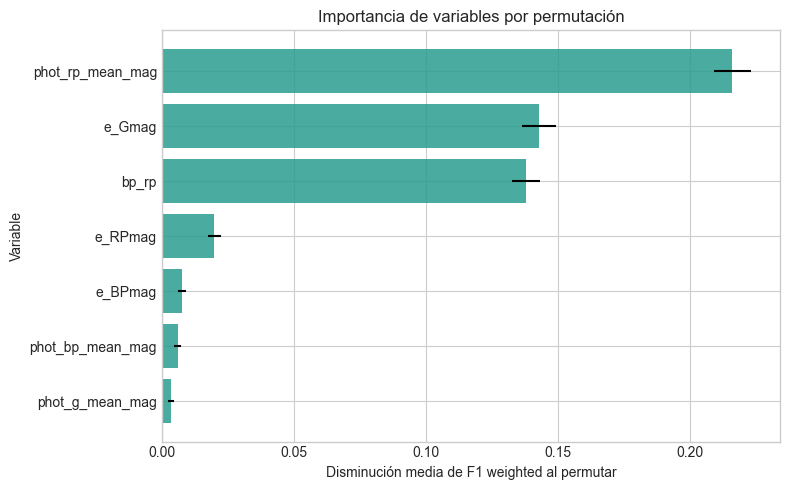

In [27]:
import os
import joblib
import pandas as pd
import matplotlib

if not hasattr(matplotlib.rcParams, '_get'):
    matplotlib.rcParams._get = matplotlib.rcParams.__getitem__

import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Cargar el artefacto del modelo guardado
ruta_modelo = 'modelo_clasificacion_estelar.joblib'
if not os.path.exists(ruta_modelo):
    raise FileNotFoundError(
        f'No se encontro {ruta_modelo}. Ejecuta antes la celda de entrenamiento/persistencia.'
    )

artefacto = joblib.load(ruta_modelo)
modelo_interp = artefacto['model'] if isinstance(artefacto, dict) and 'model' in artefacto else artefacto

# Recuperar lista de variables desde el joblib (fallback a lista conocida)
predictoras = artefacto.get('features', [
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag',
    'bp_rp',
    'e_Gmag',
    'e_BPmag',
    'e_RPmag',
]) if isinstance(artefacto, dict) else [
    'phot_g_mean_mag',
    'phot_bp_mean_mag',
    'phot_rp_mean_mag',
    'bp_rp',
    'e_Gmag',
    'e_BPmag',
    'e_RPmag',
]

# Cargar datos para interpretabilidad
csv_candidates = ['dataset_v1.csv', 'dataset_predictoras_v1.csv']
csv_usado = None
for c in csv_candidates:
    if os.path.exists(c):
        csv_usado = c
        break
if csv_usado is None:
    raise FileNotFoundError('No se encontro dataset_v1.csv ni dataset_predictoras_v1.csv.')

df_interp = pd.read_csv(csv_usado)
if 'clase_real' not in df_interp.columns:
    raise ValueError('El CSV usado para interpretabilidad no contiene la columna clase_real.')

faltantes = [c for c in predictoras if c not in df_interp.columns]
if faltantes:
    raise ValueError(f'Faltan predictoras en {csv_usado}: {faltantes}')

model_df = df_interp[predictoras + ['clase_real']].dropna().copy()
X = model_df[predictoras]
y = model_df['clase_real']

# Se usa el mismo esquema de split para medir permutacion en test
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f'Modelo cargado desde: {ruta_modelo}')
print(f'Dataset usado: {csv_usado} | Filas para interpretabilidad: {len(model_df):,}')

# Estimador interno del Pipeline (si aplica)
est_final = modelo_interp.named_steps['clf'] if hasattr(modelo_interp, 'named_steps') and 'clf' in modelo_interp.named_steps else modelo_interp

# 1) Importancia intrinseca (si el estimador la expone)
importancia_intrinseca = None
if hasattr(est_final, 'feature_importances_'):
    importancia_intrinseca = pd.DataFrame({
        'feature': predictoras,
        'importance': est_final.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)
    print('Importancia intrinseca del estimador:')
    display(importancia_intrinseca)
else:
    print('El estimador no expone feature_importances_. Se usara importancia por permutacion.')

# 2) Importancia por permutacion (agnostica al modelo)
perm = permutation_importance(
    modelo_interp,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42,
    scoring='f1_weighted',
    n_jobs=1
)
importancia_perm = pd.DataFrame({
    'feature': predictoras,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print('Importancia por permutacion (F1 weighted en test):')
display(importancia_perm)

plt.figure(figsize=(8, 5))
plt.barh(
    importancia_perm['feature'][::-1],
    importancia_perm['importance_mean'][::-1],
    xerr=importancia_perm['importance_std'][::-1],
    color='#2a9d8f',
    alpha=0.85
)
plt.title('Importancia de variables por permutación')
plt.xlabel('Disminución media de F1 weighted al permutar')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

Variables top-2 para PDP: ['phot_rp_mean_mag', 'e_Gmag']


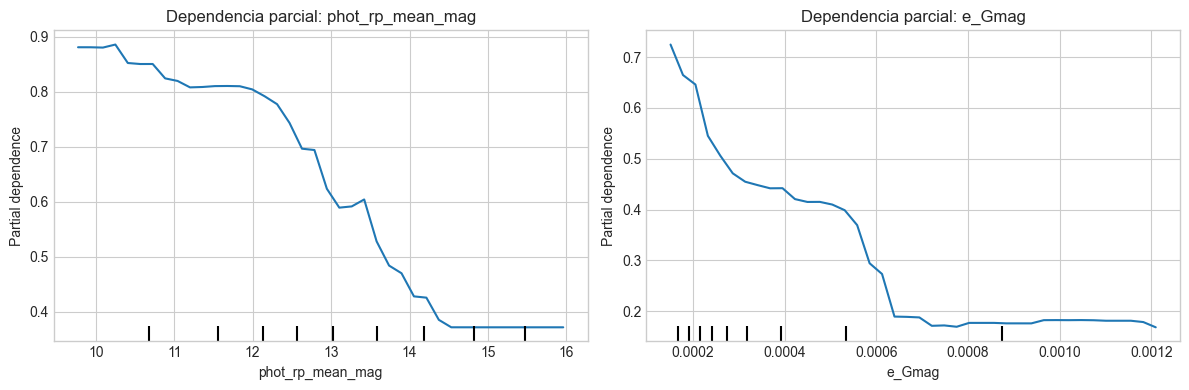

In [28]:
# Dependencia parcial de las 2 variables mas relevantes segun permutacion
features_top2 = importancia_perm['feature'].head(2).tolist()
print(f'Variables top-2 para PDP: {features_top2}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for i, feat in enumerate(features_top2):
    PartialDependenceDisplay.from_estimator(
        modelo_interp,
        X,
        [feat],
        ax=ax[i],
        grid_resolution=40,
        kind='average'
    )
    ax[i].set_title(f'Dependencia parcial: {feat}')

plt.tight_layout()
plt.show()

### 8.3 Visualización de FP y FN


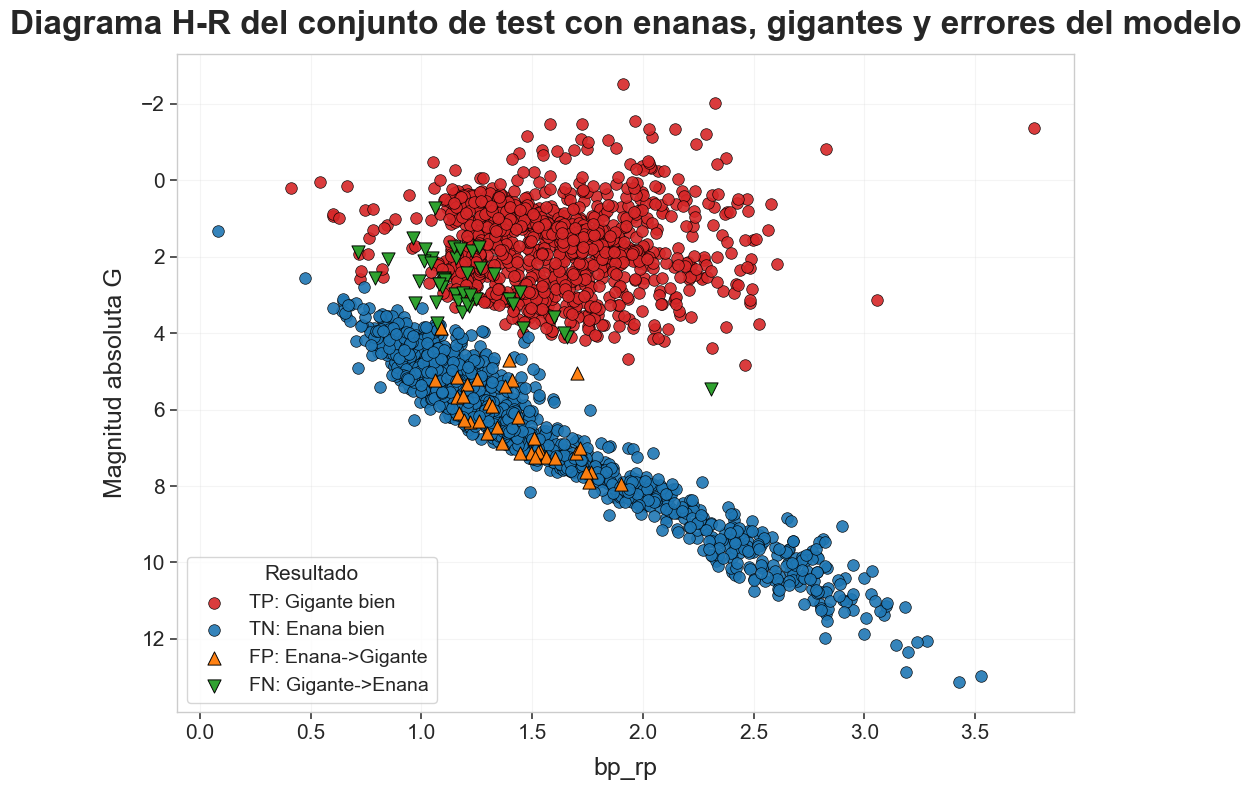

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Respetar exactamente el orden de variables con el que se entreno el modelo
orden_modelo = list(dict.fromkeys(getattr(modelo_interp, 'feature_names_in_', predictoras)))

# Construir un conjunto compatible con el modelo y con el diagrama H-R
if 'abs_mag_g' not in df.columns:
    if {'phot_g_mean_mag', 'parallax'}.issubset(df.columns):
        df = df.copy()
        df = df[df['parallax'] > 0].copy()
        df['abs_mag_g'] = df['phot_g_mean_mag'] + 5 + 5 * np.log10(df['parallax'] / 1000)
    else:
        raise ValueError('No se puede construir abs_mag_g: faltan columnas requeridas.')

if 'clase_real' not in df.columns:
    raise ValueError('No existe la columna clase_real en el dataset.')

if 'bp_rp' not in df.columns:
    raise ValueError('No existe la columna bp_rp necesaria para el diagrama H-R.')

# Mantener solo filas validas para el modelo y para el diagrama H-R
columnas_hr = list(dict.fromkeys(orden_modelo + ['clase_real', 'bp_rp', 'abs_mag_g']))
hr_df = df[columnas_hr].dropna().copy()
X_hr = hr_df[orden_modelo]
y_hr = hr_df['clase_real']

# Mismo esquema de split que el resto del notebook para que el test coincida
_, X_test, _, y_test = train_test_split(
    X_hr,
    y_hr,
    test_size=0.25,
    random_state=42,
    stratify=y_hr
)

# Recuperar las variables H-R de las mismas filas del test
hr_test = hr_df.loc[X_test.index, ['bp_rp', 'abs_mag_g', 'clase_real']].copy()

# Alinear el test con el orden real usado por el modelo y predecir sin ambiguedades de nombres
X_test_aligned = X_test.loc[:, orden_modelo]
y_pred = modelo_interp.predict(X_test_aligned.to_numpy())
hr_test['clase_pred'] = y_pred
hr_test['acierto'] = hr_test['clase_real'] == hr_test['clase_pred']

# Definir positivo/negativo de forma explicita para interpretar FP/FN
clases = sorted(hr_test['clase_real'].dropna().unique().tolist())
if set(clases) == {'Enana', 'Gigante'}:
    clase_negativa = 'Enana'
    clase_positiva = 'Gigante'
else:
    clase_negativa = clases[0]
    clase_positiva = clases[-1]

mask_tp = (hr_test['clase_real'] == clase_positiva) & (hr_test['clase_pred'] == clase_positiva)
mask_tn = (hr_test['clase_real'] == clase_negativa) & (hr_test['clase_pred'] == clase_negativa)
mask_fp = (hr_test['clase_real'] == clase_negativa) & (hr_test['clase_pred'] == clase_positiva)
mask_fn = (hr_test['clase_real'] == clase_positiva) & (hr_test['clase_pred'] == clase_negativa)



fig, ax = plt.subplots(figsize=(10, 8))

# Paleta pedida para resultados de clasificacion
colores_resultados = {
    'TP: Gigante bien': '#d62728',
    'TN: Enana bien': '#1f77b4',
    'FP: Enana->Gigante': '#ff7f0e',
    'FN: Gigante->Enana': '#2ca02c'
}



# Superponer aciertos y errores con la paleta solicitada
if mask_tp.any():
    ax.scatter(
        hr_test.loc[mask_tp, 'bp_rp'],
        hr_test.loc[mask_tp, 'abs_mag_g'],
        s=70,
        c=colores_resultados['TP: Gigante bien'],
        marker='o',
        alpha=0.9,
        edgecolors='black',
        linewidths=0.5,
        label='TP: Gigante bien'
    )
if mask_tn.any():
    ax.scatter(
        hr_test.loc[mask_tn, 'bp_rp'],
        hr_test.loc[mask_tn, 'abs_mag_g'],
        s=70,
        c=colores_resultados['TN: Enana bien'],
        marker='o',
        alpha=0.9,
        edgecolors='black',
        linewidths=0.5,
        label='TN: Enana bien'
    )
if mask_fp.any():
    ax.scatter(
        hr_test.loc[mask_fp, 'bp_rp'],
        hr_test.loc[mask_fp, 'abs_mag_g'],
        s=90,
        c=colores_resultados['FP: Enana->Gigante'],
        marker='^',
        alpha=0.98,
        edgecolors='black',
        linewidths=0.7,
        label='FP: Enana->Gigante'
    )
if mask_fn.any():
    ax.scatter(
        hr_test.loc[mask_fn, 'bp_rp'],
        hr_test.loc[mask_fn, 'abs_mag_g'],
        s=90,
        c=colores_resultados['FN: Gigante->Enana'],
        marker='v',
        alpha=0.98,
        edgecolors='black',
        linewidths=0.7,
        label='FN: Gigante->Enana'
    )

ax.set_title('Diagrama H-R del conjunto de test con enanas, gigantes y errores del modelo', fontsize=24, fontweight='bold', pad=14)
ax.set_xlabel('bp_rp', fontsize=18, labelpad=10)
ax.set_ylabel('Magnitud absoluta G', fontsize=18, labelpad=10)
ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
ax.invert_yaxis()
ax.grid(alpha=0.2)
ax.legend(loc='best', frameon=True, fontsize=14, title='Resultado', title_fontsize=15)
plt.tight_layout()
plt.show()

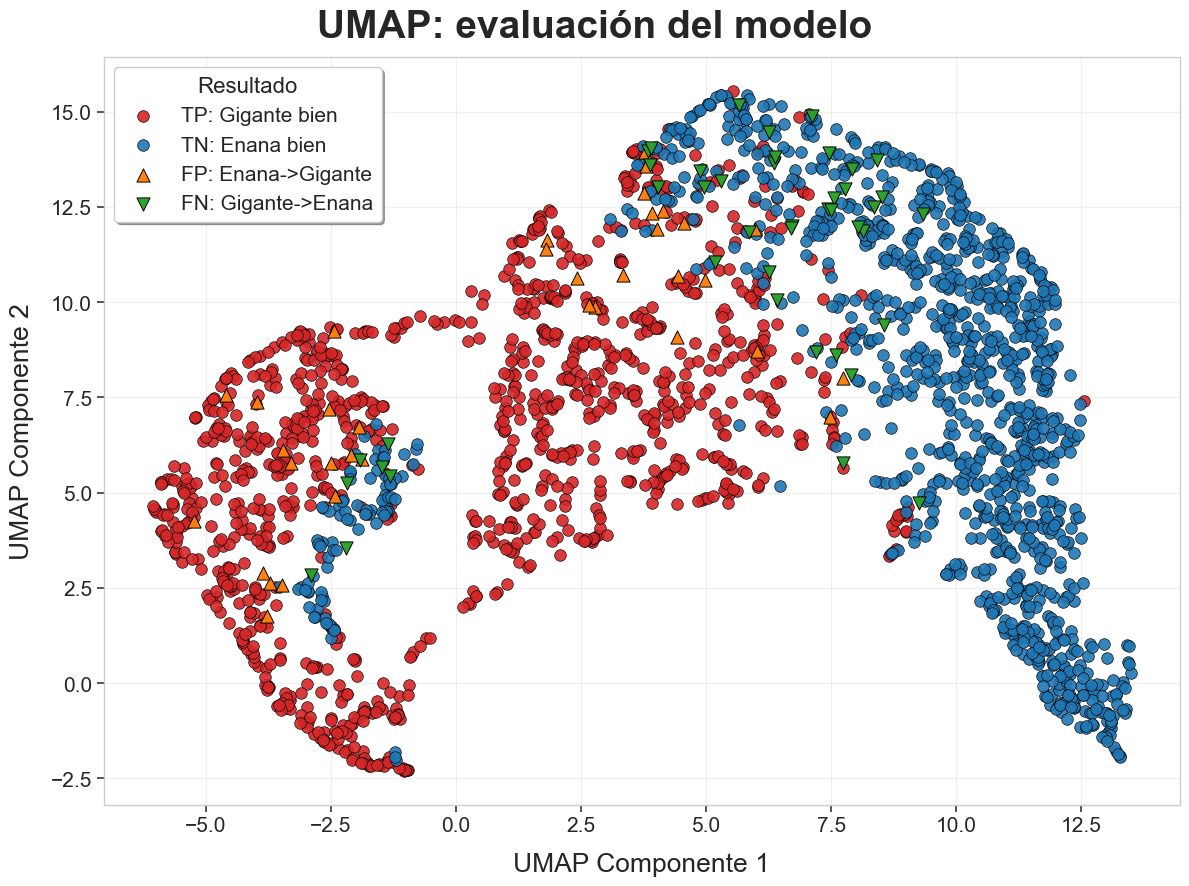

In [33]:
# 8. Visualizaciones del modelo: bp_rp vs magnitud G y UMAP del conjunto de prueba
# Nota: Usamos el UMAP entrenado con todo el dataset, no uno nuevo solo con test
# Esto asegura que los puntos de prueba estén en las mismas posiciones que en el UMAP general

if 'y_pred' not in globals():
    y_pred = mejor_modelo.predict(X_test)

feature_columns = predictoras if 'predictoras' in globals() else list(X_test.columns)

if isinstance(X_test, pd.DataFrame):
    X_test_viz = X_test.copy()
else:
    X_test_viz = pd.DataFrame(X_test, columns=feature_columns)

if hasattr(y_test, 'index'):
    indice_resultados = y_test.index
else:
    indice_resultados = X_test_viz.index

resultados = X_test_viz.copy()
resultados['clase_real'] = pd.Series(y_test, index=indice_resultados).astype(str).values
resultados['clase_predicha'] = pd.Series(y_pred, index=indice_resultados).astype(str).values

# UMAP del conjunto de prueba usando el modelo entrenado con todo el dataset
# Primero nos aseguramos de que el UMAP global existe 
if 'umap_model' not in globals() or 'scaler' not in globals():
    from sklearn.preprocessing import StandardScaler
    from umap import UMAP
    
    predictoras_cols = [
        'phot_g_mean_mag',
        'phot_bp_mean_mag',
        'phot_rp_mean_mag',
        'bp_rp',
        'e_Gmag',
        'e_BPmag',
        'e_RPmag',
    ]
    
    df_umap_temp = df[predictoras_cols + ['clase_real']].dropna()
    scaler = StandardScaler()
    X_scaled_temp = scaler.fit_transform(df_umap_temp[predictoras_cols])
    umap_model = UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1, metric='euclidean')
    umap_model.fit(X_scaled_temp)
    print('✓ UMAP global calculado')

# Ahora transformamos solo los datos de prueba usando el scaler y UMAP ya entrenados
X_test_scaled_viz = scaler.transform(resultados[feature_columns])
coords_viz = umap_model.transform(X_test_scaled_viz)
resultados['UMAP_1_viz'] = coords_viz[:, 0]
resultados['UMAP_2_viz'] = coords_viz[:, 1]

# Definir colores y marcadores por clase
colors_classes = {'Enana': '#1f77b4', 'Gigante': '#d62728'}
markers_classes = {'Enana': 'o', 'Gigante': '^'}

# Definir tipos de resultado
resultados['tipo_resultado'] = 'Correcto'
mask_tp = (resultados['clase_real'] == 'Gigante') & (resultados['clase_predicha'] == 'Gigante')
mask_tn = (resultados['clase_real'] == 'Enana') & (resultados['clase_predicha'] == 'Enana')
mask_fp = (resultados['clase_real'] == 'Enana') & (resultados['clase_predicha'] == 'Gigante')
mask_fn = (resultados['clase_real'] == 'Gigante') & (resultados['clase_predicha'] == 'Enana')

resultados.loc[mask_tp, 'tipo_resultado'] = 'TP: Gigante bien'
resultados.loc[mask_tn, 'tipo_resultado'] = 'TN: Enana bien'
resultados.loc[mask_fp, 'tipo_resultado'] = 'FP: Enana->Gigante'
resultados.loc[mask_fn, 'tipo_resultado'] = 'FN: Gigante->Enana'

# Paleta de colores para resultados
colores_resultados_umap = {
    'TP: Gigante bien': '#d62728',      # rojo: gigante correcta
    'TN: Enana bien': '#1f77b4',        # azul: enana correcta
    'FP: Enana->Gigante': '#ff7f0e',    # naranja: falso positivo
    'FN: Gigante->Enana': '#2ca02c'     # verde: falso negativo
}

# FIGURA ÚNICA: Todos los resultados
fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle('UMAP: evaluación del modelo', fontsize=28, fontweight='bold', y=0.98)

# Orden para visualizar (de manera que los errores aparezcan al frente)
orden_plot = ['TP: Gigante bien', 'TN: Enana bien', 'FP: Enana->Gigante', 'FN: Gigante->Enana']
for tipo in orden_plot:
    mask = resultados['tipo_resultado'] == tipo
    if mask.sum() > 0:
        is_error = 'F' in tipo
        ax.scatter(
            resultados.loc[mask, 'UMAP_1_viz'],
            resultados.loc[mask, 'UMAP_2_viz'],
            s=90 if is_error else 70,
            alpha=0.98 if is_error else 0.9,
            label=tipo,
            color=colores_resultados_umap[tipo],
            marker='^' if tipo == 'FP: Enana->Gigante' else ('v' if tipo == 'FN: Gigante->Enana' else 'o'),
            edgecolors='black',
            linewidths=0.7 if is_error else 0.5,
            zorder=3 if is_error else 2
        )

ax.set_xlabel('UMAP Componente 1', fontsize=19, labelpad=12)
ax.set_ylabel('UMAP Componente 2', fontsize=19, labelpad=12)
ax.tick_params(axis='both', labelsize=15, width=1.1, length=5)
ax.legend(loc='best', fontsize=15, frameon=True, shadow=True, title='Resultado', title_fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()